In [27]:
import os
for f in sorted(os.listdir('../ChineseGrandPrix')):
    print(f)

01_EDA.ipynb
02_China_ML.ipynb
F1_2026_ChineseGP_Summary.xlsx
crawl_chinese_gp.py
fp1_fastest.csv
fp1_laps.csv
fp1_weather.csv
q_fastest.csv
q_laps.csv
q_results.csv
q_weather.csv
r_fastest_laps.csv
r_laps.csv
r_pitstops.csv
r_results.csv
r_weather.csv
sprint_fastest.csv
sprint_laps.csv
sprint_pitstops.csv
sprint_results.csv
sprint_weather.csv
sq_fastest.csv
sq_laps.csv
sq_results.csv
sq_weather.csv


## 1. 📦 Setup & Config

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import os, ast, warnings
warnings.filterwarnings('ignore')

# ── Output folder ─────────────────────────────────────────────
FIG_DIR  = './figures_eda'
PROC_DIR = './processed'
os.makedirs(FIG_DIR,  exist_ok=True)
os.makedirs(PROC_DIR, exist_ok=True)

def savefig(name):
    path = f'{FIG_DIR}/{name}'
    plt.savefig(path, dpi=130, bbox_inches='tight', facecolor='#0f0f0f')
    print(f'  💾 {path}')

# ── Dark theme ────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor':'#0f0f0f', 'axes.facecolor'  :'#1a1a1a',
    'axes.edgecolor'  :'#2e2e2e', 'axes.labelcolor' :'#cccccc',
    'xtick.color'     :'#888888', 'ytick.color'     :'#888888',
    'text.color'      :'#dddddd', 'grid.color'      :'#2a2a2a',
    'grid.linestyle'  :'--',      'font.family'     :'monospace',
    'axes.titlesize'  :12,        'axes.labelsize'  :10,
    'figure.dpi'      :120,
})

TYRE_COLORS = {
    'SOFT'  :'#E8002D', 'MEDIUM':'#FFF200',
    'HARD'  :'#FFFFFF', 'INTER' :'#39B54A', 'WET':'#0067FF',
}
TEAM_COLORS = {
    'Mercedes'      :'#00D7B6', 'Ferrari'       :'#E8002D',
    'McLaren'       :'#FF8000', 'Red Bull Racing':'#3671C6',
    'Aston Martin'  :'#229971', 'Alpine'        :'#FF87BC',
    'Williams'      :'#64C4FF', 'Haas F1 Team'  :'#B6BABD',
    'Audi'          :'#52E252', 'Racing Bulls'  :'#6692FF',
    'Cadillac'      :'#C8AA6E',
}

# Sprint weekend — không có FP2/FP3
SESSIONS_ORDER = ['FP1','SQ','Sprint','Qualifying','Race']

print('✅ Setup done')
print(f'   Figures  → {FIG_DIR}/')
print(f'   Processed→ {PROC_DIR}/')


✅ Setup done
   Figures  → ./figures_eda/
   Processed→ ./processed/


## 2. 📂 Load Raw Data

In [29]:
DATA_DIR = '../ChineseGrandPrix'   # ← đổi nếu cần

# ── Fastest laps ──────────────────────────────────────────────
fp1_raw    = pd.read_csv(f'{DATA_DIR}/fp1_fastest.csv',    index_col=0)
sq_raw     = pd.read_csv(f'{DATA_DIR}/sq_fastest.csv',     index_col=0)
sprint_raw = pd.read_csv(f'{DATA_DIR}/sprint_fastest.csv', index_col=0)
q_raw      = pd.read_csv(f'{DATA_DIR}/q_fastest.csv',      index_col=0)

# ── Lap data ──────────────────────────────────────────────────
fp1_laps_raw    = pd.read_csv(f'{DATA_DIR}/fp1_laps.csv')
sq_laps_raw     = pd.read_csv(f'{DATA_DIR}/sq_laps.csv')
sprint_laps_raw = pd.read_csv(f'{DATA_DIR}/sprint_laps.csv')
q_laps_raw      = pd.read_csv(f'{DATA_DIR}/q_laps.csv')
r_laps_raw      = pd.read_csv(f'{DATA_DIR}/r_laps.csv')

# ── Results ───────────────────────────────────────────────────
sq_res_raw     = pd.read_csv(f'{DATA_DIR}/sq_results.csv')
sprint_res_raw = pd.read_csv(f'{DATA_DIR}/sprint_results.csv')
q_res_raw      = pd.read_csv(f'{DATA_DIR}/q_results.csv')
r_res_raw      = pd.read_csv(f'{DATA_DIR}/r_results.csv')

# ── Pit stops ─────────────────────────────────────────────────
sprint_pit_raw = pd.read_csv(f'{DATA_DIR}/sprint_pitstops.csv')
r_pit_raw      = pd.read_csv(f'{DATA_DIR}/r_pitstops.csv')

# ── Race fastest laps ─────────────────────────────────────────
r_fast_raw = pd.read_csv(f'{DATA_DIR}/r_fastest_laps.csv')

# ── Weather ───────────────────────────────────────────────────
fp1_w_raw    = pd.read_csv(f'{DATA_DIR}/fp1_weather.csv')
sq_w_raw     = pd.read_csv(f'{DATA_DIR}/sq_weather.csv')
sprint_w_raw = pd.read_csv(f'{DATA_DIR}/sprint_weather.csv')
q_w_raw      = pd.read_csv(f'{DATA_DIR}/q_weather.csv')
r_w_raw      = pd.read_csv(f'{DATA_DIR}/r_weather.csv')

print('✅ Raw data loaded')
print(f'   FP1 fastest: {fp1_raw.shape} | SQ: {sq_raw.shape} | Sprint: {sprint_raw.shape} | Q: {q_raw.shape}')
print(f'   FP1 laps: {fp1_laps_raw.shape} | SQ laps: {sq_laps_raw.shape}')
print(f'   Sprint laps: {sprint_laps_raw.shape} | Q laps: {q_laps_raw.shape} | Race laps: {r_laps_raw.shape}')
print(f'   Race results: {r_res_raw.shape} | Sprint results: {sprint_res_raw.shape}')


✅ Raw data loaded
   FP1 fastest: (22, 11) | SQ: (21, 11) | Sprint: (22, 11) | Q: (22, 11)
   FP1 laps: (540, 19) | SQ laps: (257, 19)
   Sprint laps: (397, 19) | Q laps: (325, 19) | Race laps: (924, 19)
   Race results: (22, 22) | Sprint results: (22, 22)


## 3. 🧹 Data Cleaning

| # | Vấn đề | Xử lý |
|---|--------|-------|
| 1 | Cột `LapTime` dạng string | Drop — đã có `LapTime_s` float |
| 2 | `IsPersonalBest` NaN / dtype object | `fillna(False).astype(bool)` |
| 3 | Q1/Q2/Q3 dạng timedelta string | Parse → giây (float) |
| 4 | `GridPosition` NaN trong results | Map từ race results |
| 5 | Weather `Time` dạng timedelta string | Parse → giây (float) |
| 6 | `PitLaps` dạng string list | Parse → list of int |
| 7 | Out-laps / lap không có LapTime | Drop NaN + filter outlier >150% median |


In [30]:
# ── 3.1 Fastest lap tables ────────────────────────────────────
def clean_fastest(df, session_name):
    df = df.copy()
    # Drop cột LapTime string (giữ LapTime_s float)
    if 'LapTime' in df.columns:
        df = df.drop(columns=['LapTime'])
    # Rename Gap
    if 'Gap_to_Best_s' in df.columns:
        df = df.rename(columns={'Gap_to_Best_s': 'Gap_s'})
    df['DriverNumber'] = pd.to_numeric(df['DriverNumber'], errors='coerce')
    df = df.reset_index(drop=True)
    print(f'  {session_name:20s}: {len(df)} drivers')
    return df

print('Fastest lap tables:')
fp1    = clean_fastest(fp1_raw,    'FP1')
sq     = clean_fastest(sq_raw,     'Sprint Qualifying')
sprint = clean_fastest(sprint_raw, 'Sprint')
q      = clean_fastest(q_raw,      'Qualifying')


Fastest lap tables:
  FP1                 : 22 drivers
  Sprint Qualifying   : 21 drivers
  Sprint              : 22 drivers
  Qualifying          : 22 drivers


In [31]:
# ── 3.2 Lap tables ────────────────────────────────────────────
def clean_laps(df, session_name):
    df = df.copy()
    # IsPersonalBest → bool
    if 'IsPersonalBest' in df.columns:
        df['IsPersonalBest'] = df['IsPersonalBest'].fillna(False).astype(bool)
    if 'FreshTyre' in df.columns:
        df['FreshTyre'] = df['FreshTyre'].fillna(False).astype(bool)
    # Drop lap không có LapTime
    n_before = len(df)
    df = df.dropna(subset=['LapTime_s']).reset_index(drop=True)
    # Drop outlier >150% median (out-lap, SC lap)
    med = df['LapTime_s'].median()
    df  = df[df['LapTime_s'] < med * 1.5].reset_index(drop=True)
    print(f'  {session_name:20s}: {n_before} → {len(df)} laps')
    return df

print('Lap tables:')
fp1_laps    = clean_laps(fp1_laps_raw,    'FP1')
sq_laps     = clean_laps(sq_laps_raw,     'Sprint Qualifying')
sprint_laps = clean_laps(sprint_laps_raw, 'Sprint')
q_laps      = clean_laps(q_laps_raw,      'Qualifying')
r_laps      = clean_laps(r_laps_raw,      'Race')


Lap tables:
  FP1                 : 540 → 432 laps
  Sprint Qualifying   : 257 → 208 laps
  Sprint              : 397 → 362 laps
  Qualifying          : 325 → 232 laps
  Race                : 924 → 895 laps


In [32]:
# ── 3.3 Results tables ────────────────────────────────────────
def parse_td(val):
    """timedelta string → float seconds"""
    try:    return pd.to_timedelta(val).total_seconds()
    except: return np.nan

def clean_results(df, session_name):
    df = df.copy()
    df = df.rename(columns={'Abbreviation':'Driver', 'TeamName':'Team'})
    df['Position']     = pd.to_numeric(df['Position'],     errors='coerce')
    df['GridPosition'] = pd.to_numeric(df['GridPosition'], errors='coerce')
    df['Points']       = pd.to_numeric(df['Points'],       errors='coerce')
    df['Laps']         = pd.to_numeric(df['Laps'],         errors='coerce')
    df['dnf']          = df['Status'].isin(['Retired','Did not start','Disqualified'])
    df['finished']     = df['Status'] == 'Finished'
    # Parse Q1/Q2/Q3 nếu có
    for col in ['Q1','Q2','Q3']:
        if col in df.columns:
            df[f'{col}_s'] = df[col].apply(parse_td)
    print(f'  {session_name:20s}: {len(df)} drivers | DNF: {df["dnf"].sum()}')
    return df

print('Results tables:')
sq_res     = clean_results(sq_res_raw,     'Sprint Qualifying')
sprint_res = clean_results(sprint_res_raw, 'Sprint')
q_res      = clean_results(q_res_raw,      'Qualifying')
r_res      = clean_results(r_res_raw,      'Race')

# GridPosition map từ race results (nguồn chính xác nhất)
GRID_MAP = dict(zip(r_res['Driver'], r_res['GridPosition']))
print(f'\nGrid positions: {GRID_MAP}')


Results tables:
  Sprint Qualifying   : 22 drivers | DNF: 0
  Sprint              : 22 drivers | DNF: 3
  Qualifying          : 22 drivers | DNF: 0
  Race                : 22 drivers | DNF: 7

Grid positions: {'ANT': 1.0, 'RUS': 2.0, 'HAM': 3.0, 'LEC': 4.0, 'BEA': 10.0, 'GAS': 7.0, 'LAW': 14.0, 'HAD': 9.0, 'SAI': 17.0, 'COL': 12.0, 'HUL': 11.0, 'LIN': 15.0, 'BOT': 19.0, 'OCO': 13.0, 'PER': 21.0, 'VER': 8.0, 'ALO': 18.0, 'STR': 20.0, 'PIA': 5.0, 'NOR': 6.0, 'BOR': 16.0, 'ALB': 22.0}


In [33]:
# ── 3.4 Pit stops ─────────────────────────────────────────────
def clean_pits(df, session_name):
    df = df.copy()
    def parse_laps(val):
        try:    return [int(x) for x in ast.literal_eval(str(val))]
        except: return []
    df['pit_laps']  = df['PitLaps'].apply(parse_laps)
    df['first_pit'] = df['pit_laps'].apply(lambda x: min(x) if x else np.nan)
    df['last_pit']  = df['pit_laps'].apply(lambda x: max(x) if x else np.nan)
    df = df.drop(columns=['PitLaps'])
    df = df.rename(columns={'Stops':'pit_stops'})
    print(f'  {session_name:20s}: {len(df)} drivers pit')
    return df

print('Pit stops:')
sprint_pit = clean_pits(sprint_pit_raw, 'Sprint')
r_pit      = clean_pits(r_pit_raw,      'Race')


Pit stops:
  Sprint              : 14 drivers pit
  Race                : 17 drivers pit


In [34]:
# ── 3.5 Weather ───────────────────────────────────────────────
def clean_weather(df, session_name):
    df = df.copy()
    df['Time_s']  = df['Time'].apply(parse_td)
    df['Rainfall'] = df['Rainfall'].astype(bool)
    df['session']  = session_name
    return df.drop(columns=['Time'])

fp1_w    = clean_weather(fp1_w_raw,    'FP1')
sq_w     = clean_weather(sq_w_raw,     'Sprint Qualifying')
sprint_w = clean_weather(sprint_w_raw, 'Sprint')
q_w      = clean_weather(q_w_raw,      'Qualifying')
r_w      = clean_weather(r_w_raw,      'Race')

weather_all = pd.concat([fp1_w, sq_w, sprint_w, q_w, r_w], ignore_index=True)

summary_w = pd.DataFrame([
    {'Session':df['session'].iloc[0],
     'AirTemp_mean' :df['AirTemp'].mean().round(1),
     'AirTemp_max'  :df['AirTemp'].max(),
     'TrackTemp_mean':df['TrackTemp'].mean().round(1),
     'TrackTemp_max' :df['TrackTemp'].max(),
     'Humidity_mean' :df['Humidity'].mean().round(1),
     'Rainfall'      :df['Rainfall'].any()}
    for df in [fp1_w, sq_w, sprint_w, q_w, r_w]
])
print('\nWeather summary:')
print(summary_w.to_string(index=False))

# Helper maps
driver_team  = dict(zip(r_res['Driver'], r_res['Team']))
driver_color = {d: TEAM_COLORS.get(t,'#888888') for d,t in driver_team.items()}
print('\n✅ Cleaning done')



Weather summary:
          Session  AirTemp_mean  AirTemp_max  TrackTemp_mean  TrackTemp_max  Humidity_mean  Rainfall
              FP1          13.0         14.0            21.3           27.7           36.7     False
Sprint Qualifying          16.4         16.9            28.2           30.9           25.8     False
           Sprint          14.9         15.7            15.4           22.7           49.4     False
       Qualifying          17.8         18.3            31.0           32.5           34.4     False
             Race          15.6         16.4            22.6           27.6           55.0     False

✅ Cleaning done


## 4. 🔗 Merge → Master Tables

In [35]:
# ══════════════════════════════════════════════════════════════
# df_drivers: 1 row per driver
# Gộp: FP1 + SQ + Sprint + Qualifying + Race
# ══════════════════════════════════════════════════════════════

# FP1 — bỏ Team, lấy từ race_m sau
fp1_m = fp1[['Driver','DriverNumber',
             'LapTime_s','Sector1Time_s','Sector2Time_s','Sector3Time_s',
             'SpeedFL','Gap_s']].copy()
fp1_m.columns = ['Driver','DriverNumber',
                 'fp1_laptime','fp1_s1','fp1_s2','fp1_s3','fp1_speed','fp1_gap']

# Sprint Qualifying
sq_m = sq[['Driver','LapTime_s','Sector1Time_s','Sector2Time_s','Sector3Time_s',
           'SpeedFL','Gap_s']].copy()
sq_m.columns = ['Driver','sq_laptime','sq_s1','sq_s2','sq_s3','sq_speed','sq_gap']

# Sprint fastest
sprint_m = sprint[['Driver','LapTime_s','Sector1Time_s','Sector2Time_s','Sector3Time_s',
                   'SpeedFL','Gap_s']].copy()
sprint_m.columns = ['Driver','sprint_laptime','sprint_s1','sprint_s2','sprint_s3',
                    'sprint_speed','sprint_gap']

# Qualifying
q_m = q[['Driver','LapTime_s','Sector1Time_s','Sector2Time_s','Sector3Time_s',
         'SpeedFL','Gap_s']].copy()
q_m.columns = ['Driver','quali_laptime','quali_s1','quali_s2','quali_s3',
               'quali_speed','quali_gap']

# Qualifying results (Q1/Q2/Q3 + grid)
qr_m = q_res[['Driver','Q1_s','Q2_s','Q3_s','GridPosition',
               'eliminated_Q1' if 'eliminated_Q1' in q_res.columns else 'Q1_s']].copy()
# Tính eliminated flags
q_res['eliminated_Q1'] = q_res['Q2_s'].isna()
q_res['eliminated_Q2'] = (~q_res['Q2_s'].isna()) & q_res['Q3_s'].isna()
q_res['reached_Q3']    = q_res['Q3_s'].notna()
qr_m = q_res[['Driver','Q1_s','Q2_s','Q3_s',
               'eliminated_Q1','eliminated_Q2','reached_Q3']].copy()

# Sprint results
sprint_res_m = sprint_res[['Driver','Position','Status','Points']].copy()
sprint_res_m.columns = ['Driver','sprint_pos','sprint_status','sprint_points']

# Race results
race_m = r_res[['Driver','Team','Position','ClassifiedPosition',
                'GridPosition','Status','Points','Laps','dnf','finished']].copy()
race_m.columns = ['Driver','Team','race_pos','classified_pos',
                  'grid_pos','race_status','race_points','race_laps','dnf','finished']

# GridPosition từ GRID_MAP (chính xác nhất)
race_m['grid_pos'] = race_m['Driver'].map(GRID_MAP)
race_m['positions_gained'] = race_m['grid_pos'] - race_m['race_pos']

# Pit stops
pit_m = r_pit[['Driver','pit_stops','pit_laps','first_pit','last_pit']].copy()

# Race fastest lap
fast_m = r_fast_raw[['Driver','LapTime','SpeedFL','Compound']].copy()
fast_m.columns = ['Driver','race_fastest_s','race_fastest_speed','race_fastest_compound']

# ── MERGE ─────────────────────────────────────────────────────
df_drivers = (
    fp1_m
    .merge(sq_m,        on='Driver', how='outer')
    .merge(sprint_m,    on='Driver', how='outer')
    .merge(q_m,         on='Driver', how='outer')
    .merge(qr_m,        on='Driver', how='left')
    .merge(sprint_res_m,on='Driver', how='left')
    .merge(race_m,      on='Driver', how='left')
    .merge(pit_m,       on='Driver', how='left')
    .merge(fast_m,      on='Driver', how='left')
)

# ── Fix GridPosition ──────────────────────────────────────────
df_drivers['grid_pos'] = df_drivers['Driver'].map(GRID_MAP)

# ── Engineered features ───────────────────────────────────────
df_drivers['fp1_to_sq_delta']     = df_drivers['fp1_laptime'] - df_drivers['sq_laptime']
df_drivers['sq_to_quali_delta']   = df_drivers['sq_laptime']  - df_drivers['quali_laptime']
df_drivers['quali_vs_sprint']     = df_drivers['quali_laptime'] - df_drivers['sprint_laptime']
df_drivers['sq_sector_std']       = df_drivers[['sq_s1','sq_s2','sq_s3']].std(axis=1)
df_drivers['sprint_sector_std']   = df_drivers[['sprint_s1','sprint_s2','sprint_s3']].std(axis=1)
df_drivers['sprint_pos_gained']   = df_drivers['grid_pos'] - df_drivers['sprint_pos']

# FillNA cho các delta (driver thiếu FP1)
for col in ['fp1_to_sq_delta','sq_to_quali_delta']:
    df_drivers[col] = df_drivers[col].fillna(df_drivers[col].median())

df_drivers['team_color'] = df_drivers['Team'].map(TEAM_COLORS).fillna('#888888')
df_drivers = df_drivers.sort_values('race_pos').reset_index(drop=True)

print(f'✅ df_drivers: {df_drivers.shape}')
print()

# Null check
null_check = df_drivers.isnull().sum()
null_check = null_check[null_check > 0]
print('Null counts (non-zero):')
for col, cnt in null_check.items():
    pct = cnt/len(df_drivers)*100
    print(f'  {col:35s}: {cnt} ({pct:.0f}%)')


✅ df_drivers: (22, 59)

Null counts (non-zero):
  sq_laptime                         : 1 (5%)
  sq_s1                              : 1 (5%)
  sq_s2                              : 1 (5%)
  sq_s3                              : 1 (5%)
  sq_speed                           : 1 (5%)
  sq_gap                             : 1 (5%)
  Q2_s                               : 6 (27%)
  Q3_s                               : 12 (55%)
  pit_stops                          : 5 (23%)
  pit_laps                           : 5 (23%)
  first_pit                          : 5 (23%)
  last_pit                           : 5 (23%)
  race_fastest_s                     : 4 (18%)
  race_fastest_speed                 : 4 (18%)
  race_fastest_compound              : 4 (18%)
  sq_sector_std                      : 1 (5%)


In [36]:
# ── df_laps: gộp tất cả sessions ─────────────────────────────
COMMON = ['Driver','DriverNumber','Team','LapNumber',
          'LapTime_s','Sector1Time_s','Sector2Time_s','Sector3Time_s',
          'SpeedI1','SpeedI2','SpeedFL','SpeedST',
          'Compound','TyreLife','FreshTyre','IsPersonalBest','TrackStatus']

def tag(df, session):
    df = df.copy()
    df['session'] = session
    keep = ['session'] + [c for c in COMMON if c in df.columns]
    return df[keep]

SESSION_ORDER = {'FP1':1,'SQ':2,'Sprint':3,'Qualifying':4,'Race':5}

df_laps = pd.concat([
    tag(fp1_laps,    'FP1'),
    tag(sq_laps,     'SQ'),
    tag(sprint_laps, 'Sprint'),
    tag(q_laps,      'Qualifying'),
    tag(r_laps,      'Race'),
], ignore_index=True)

df_laps['session_order'] = df_laps['session'].map(SESSION_ORDER)
df_laps = df_laps.sort_values(['session_order','Driver','LapNumber']).reset_index(drop=True)

print(f'✅ df_laps: {df_laps.shape}')
print()
print(df_laps.groupby('session')['LapTime_s'].agg(['count','mean','min']).round(3))

print()
print('df_drivers preview:')
preview_cols = ['Driver','Team','fp1_laptime','sq_laptime','quali_laptime',
                'grid_pos','sprint_pos','race_pos','pit_stops','race_status']
print(df_drivers[preview_cols].to_string(index=False))


✅ df_laps: (2129, 19)

            count     mean     min
session                           
FP1           432  111.038  92.741
Qualifying    232  108.842  92.064
Race          895  100.371  95.275
SQ            208  109.622  91.520
Sprint        362  104.828  94.753

df_drivers preview:
Driver            Team  fp1_laptime  sq_laptime  quali_laptime  grid_pos  sprint_pos  race_pos  pit_stops   race_status
   ANT        Mercedes       92.861      91.809         92.064       1.0         5.0       1.0        1.0      Finished
   RUS        Mercedes       92.741      91.520         92.286       2.0         1.0       2.0        1.0      Finished
   HAM         Ferrari       94.129      92.161         92.415       3.0         3.0       3.0        1.0      Finished
   LEC         Ferrari       93.599      92.528         92.428       4.0         2.0       4.0        1.0      Finished
   BEA    Haas F1 Team       94.426      93.409         93.197      10.0         8.0       5.0        1.0      

## 5. 📊 FP1 Analysis

  💾 ./figures_eda/01_fp1_analysis.png


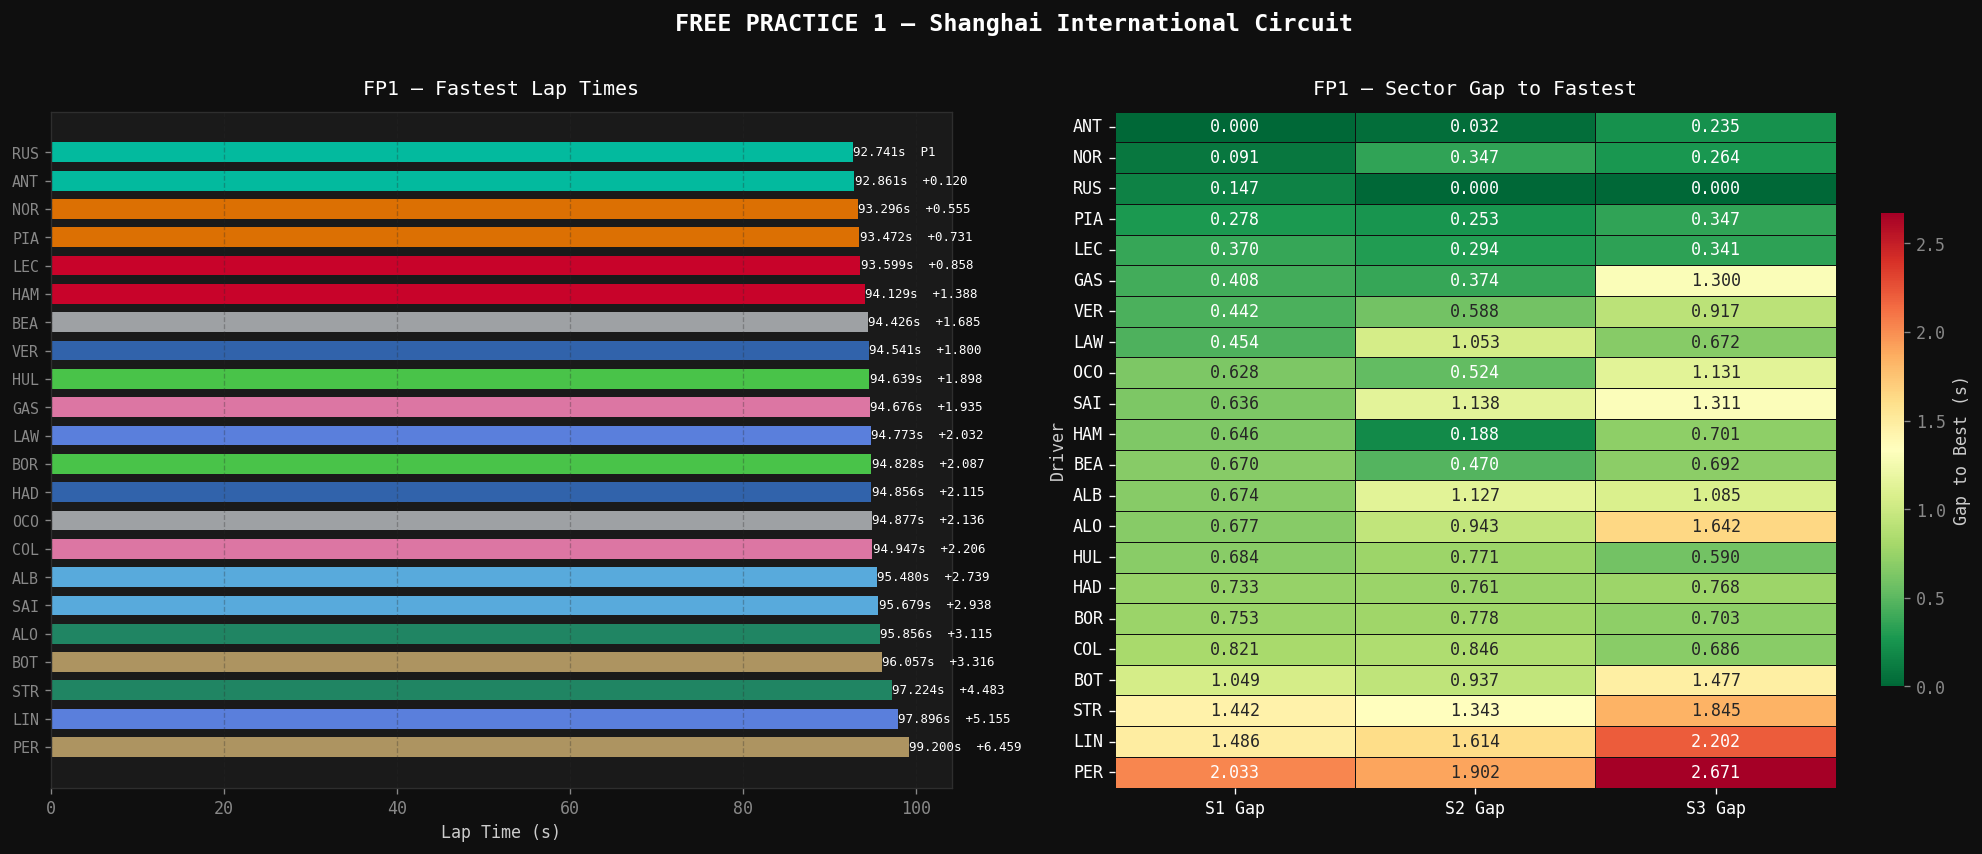

In [37]:
# ── 5.1 FP1 pace + sector heatmap ────────────────────────────
fp1_plot = fp1.sort_values('LapTime_s').copy()
fp1_plot['color'] = fp1_plot['Driver'].map(driver_color)

fig, axes = plt.subplots(1, 2, figsize=(17, 7))
fig.patch.set_facecolor('#0f0f0f')

# Left: lap time bar
ax = axes[0]
ax.barh(range(len(fp1_plot)), fp1_plot['LapTime_s'],
        color=fp1_plot['color'], alpha=0.85, height=0.7)
ax.set_yticks(range(len(fp1_plot)))
ax.set_yticklabels(fp1_plot['Driver'], fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Lap Time (s)')
ax.set_title('FP1 — Fastest Lap Times', color='white', pad=10)
ax.grid(axis='x', alpha=0.3)
for i, row in fp1_plot.iterrows():
    idx = fp1_plot.index.get_loc(i)
    ax.text(row['LapTime_s']+0.05, idx,
            f'{row["LapTime_s"]:.3f}s  +{row["Gap_s"]:.3f}' if row['Gap_s']>0
            else f'{row["LapTime_s"]:.3f}s  P1',
            va='center', fontsize=7.5, color='white')

# Right: sector heatmap
ax2 = axes[1]
sec = fp1[['Driver','Sector1Time_s','Sector2Time_s','Sector3Time_s']].set_index('Driver')
sec_gap = sec.copy()
for col in sec_gap.columns:
    sec_gap[col] = (sec_gap[col] - sec_gap[col].min()).round(3)
sec_gap.columns = ['S1 Gap','S2 Gap','S3 Gap']
sec_gap = sec_gap.sort_values('S1 Gap')
sns.heatmap(sec_gap, ax=ax2, cmap='RdYlGn_r', annot=True, fmt='.3f',
            linewidths=0.4, linecolor='#0f0f0f',
            cbar_kws={'label':'Gap to Best (s)','shrink':0.7})
ax2.set_title('FP1 — Sector Gap to Fastest', color='white', pad=10)
ax2.tick_params(colors='white')

plt.suptitle('FREE PRACTICE 1 — Shanghai International Circuit',
             color='white', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); savefig('01_fp1_analysis.png'); plt.show()


## 6. 🏁 Sprint Qualifying Analysis

  💾 ./figures_eda/02_sprint_qualifying.png


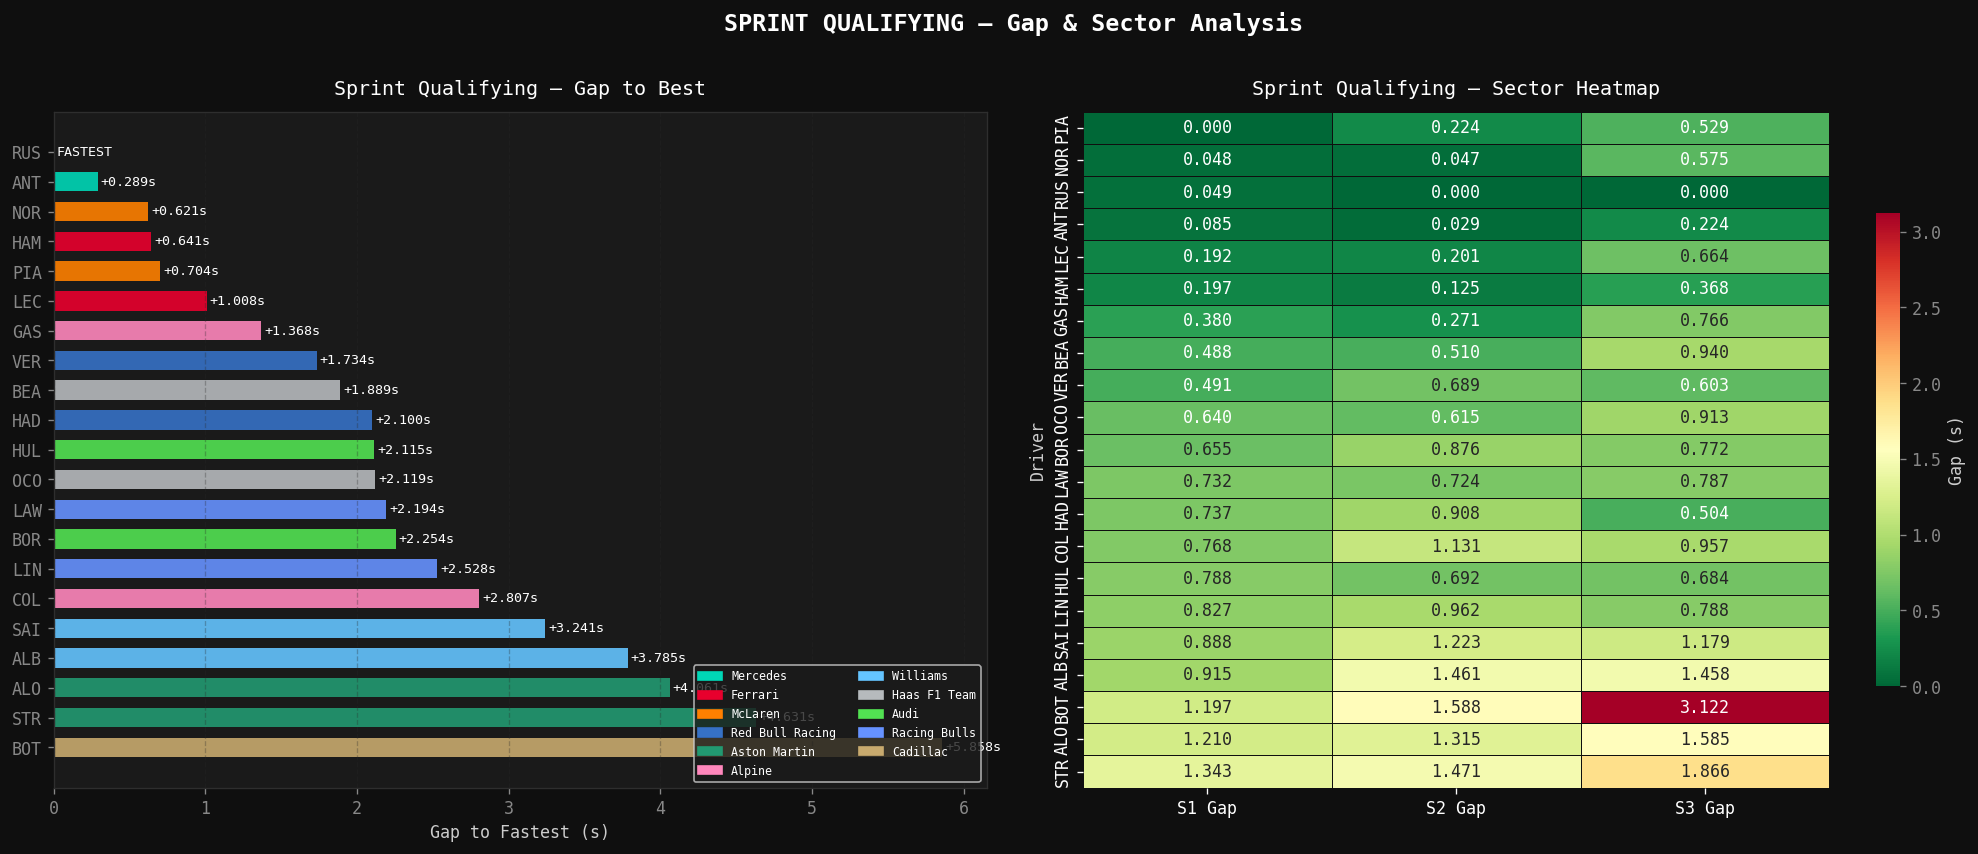

In [38]:
# ── 6.1 SQ gap to best ───────────────────────────────────────
sq_plot = sq.sort_values('Gap_s').copy()
sq_plot['color'] = sq_plot['Driver'].map(driver_color)

fig, axes = plt.subplots(1, 2, figsize=(17, 7))
fig.patch.set_facecolor('#0f0f0f')

ax = axes[0]
for _, row in sq_plot.iterrows():
    ax.barh(row['Driver'], row['Gap_s'], color=row['color'], alpha=0.9, height=0.65)
    label = f'+{row["Gap_s"]:.3f}s' if row['Gap_s']>0 else 'FASTEST'
    ax.text(row['Gap_s']+0.02, row['Driver'], label, va='center', fontsize=8, color='white')
ax.invert_yaxis()
ax.set_xlabel('Gap to Fastest (s)')
ax.set_title('Sprint Qualifying — Gap to Best', color='white', pad=10)
ax.grid(axis='x', alpha=0.3)
legend_items = [mpatches.Patch(color=c, label=t)
                for t,c in TEAM_COLORS.items() if t in driver_team.values()]
ax.legend(handles=legend_items, loc='lower right',
          facecolor='#1a1a1a', labelcolor='white', fontsize=7, ncol=2)

# Sector comparison SQ vs FP1
ax2 = axes[1]
sq_sec  = sq[['Driver','Sector1Time_s','Sector2Time_s','Sector3Time_s']].set_index('Driver')
sq_sec_gap = sq_sec.copy()
for col in sq_sec_gap.columns:
    sq_sec_gap[col] = (sq_sec_gap[col] - sq_sec_gap[col].min()).round(3)
sq_sec_gap.columns = ['S1 Gap','S2 Gap','S3 Gap']
sq_sec_gap = sq_sec_gap.sort_values('S1 Gap')
sns.heatmap(sq_sec_gap, ax=ax2, cmap='RdYlGn_r', annot=True, fmt='.3f',
            linewidths=0.4, linecolor='#0f0f0f',
            cbar_kws={'label':'Gap (s)','shrink':0.7})
ax2.set_title('Sprint Qualifying — Sector Heatmap', color='white', pad=10)
ax2.tick_params(colors='white')

plt.suptitle('SPRINT QUALIFYING — Gap & Sector Analysis',
             color='white', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); savefig('02_sprint_qualifying.png'); plt.show()


  💾 ./figures_eda/03_fp1_vs_sq.png


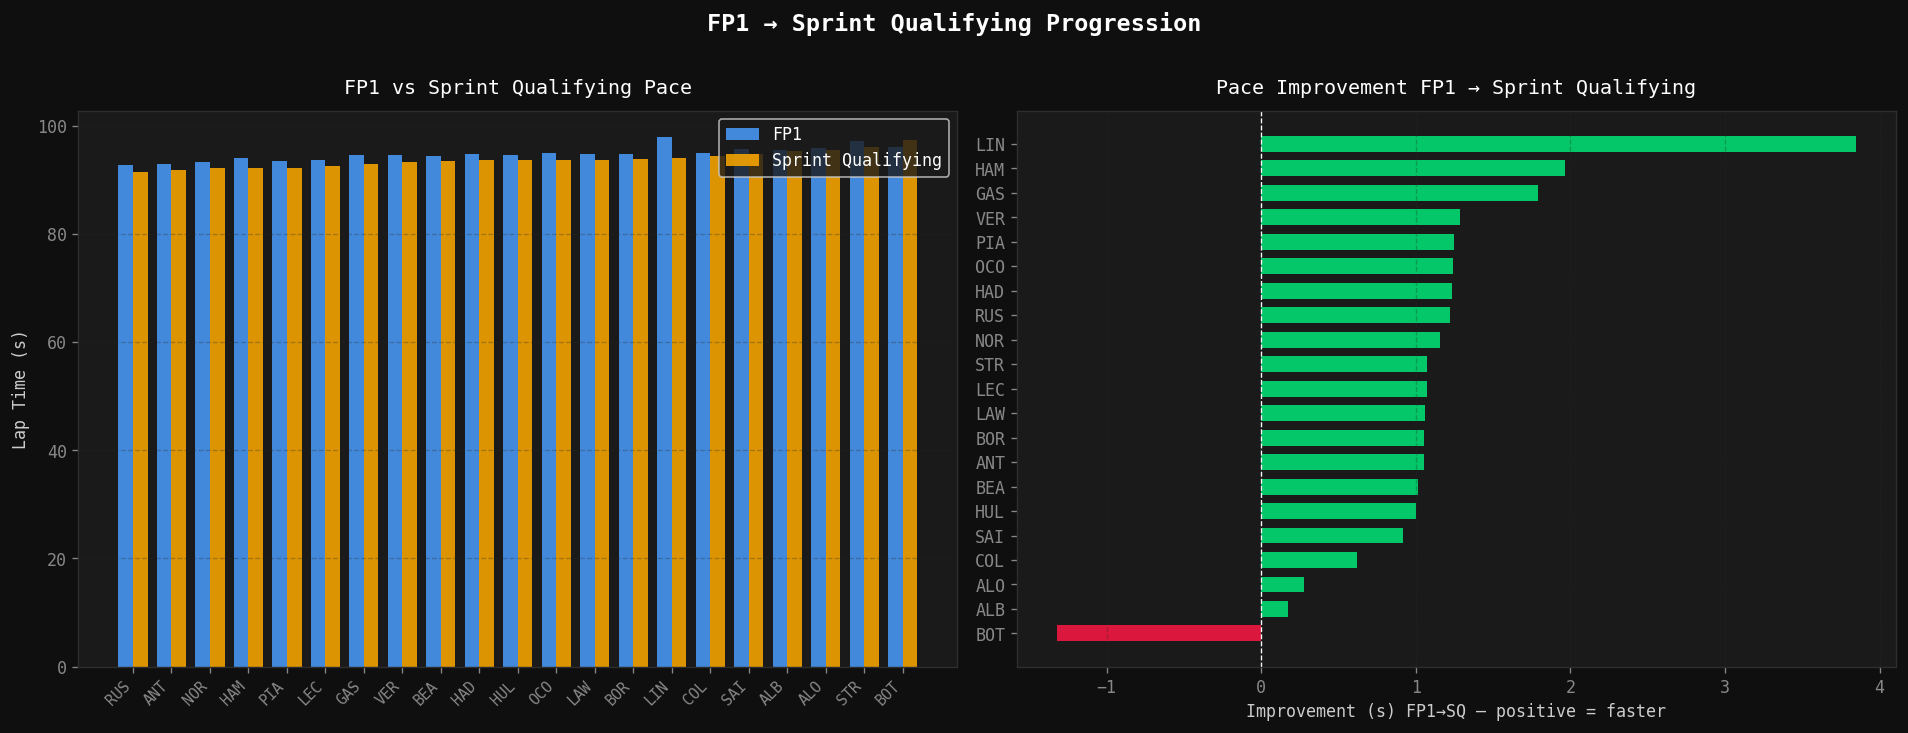

In [39]:
# ── 6.2 SQ vs FP1 pace comparison ────────────────────────────
pace_cmp = fp1[['Driver','LapTime_s']].rename(columns={'LapTime_s':'FP1'})\
    .merge(sq[['Driver','LapTime_s']].rename(columns={'LapTime_s':'SQ'}), on='Driver')
pace_cmp['improvement'] = pace_cmp['FP1'] - pace_cmp['SQ']
pace_cmp = pace_cmp.sort_values('SQ')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0f0f0f')

ax = axes[0]
x, w = np.arange(len(pace_cmp)), 0.38
ax.bar(x-w/2, pace_cmp['FP1'], width=w, color='#4a9eff', alpha=0.85, label='FP1')
ax.bar(x+w/2, pace_cmp['SQ'],  width=w, color='#ffaa00', alpha=0.85, label='Sprint Qualifying')
ax.set_xticks(x); ax.set_xticklabels(pace_cmp['Driver'], rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Lap Time (s)'); ax.set_title('FP1 vs Sprint Qualifying Pace', color='white', pad=10)
ax.legend(facecolor='#1a1a1a', labelcolor='white'); ax.grid(axis='y', alpha=0.3)

ax2 = axes[1]
imp = pace_cmp.sort_values('improvement', ascending=True)
bar_c = ['#00e676' if v>=0 else '#ff1744' for v in imp['improvement']]
ax2.barh(imp['Driver'], imp['improvement'], color=bar_c, alpha=0.85, height=0.65)
ax2.axvline(0, color='white', linewidth=0.8, linestyle='--')
ax2.set_xlabel('Improvement (s) FP1→SQ — positive = faster')
ax2.set_title('Pace Improvement FP1 → Sprint Qualifying', color='white', pad=10)
ax2.grid(axis='x', alpha=0.3)

plt.suptitle('FP1 → Sprint Qualifying Progression',
             color='white', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); savefig('03_fp1_vs_sq.png'); plt.show()


## 7. ⚡ Sprint Race Analysis

  💾 ./figures_eda/04_sprint_race.png


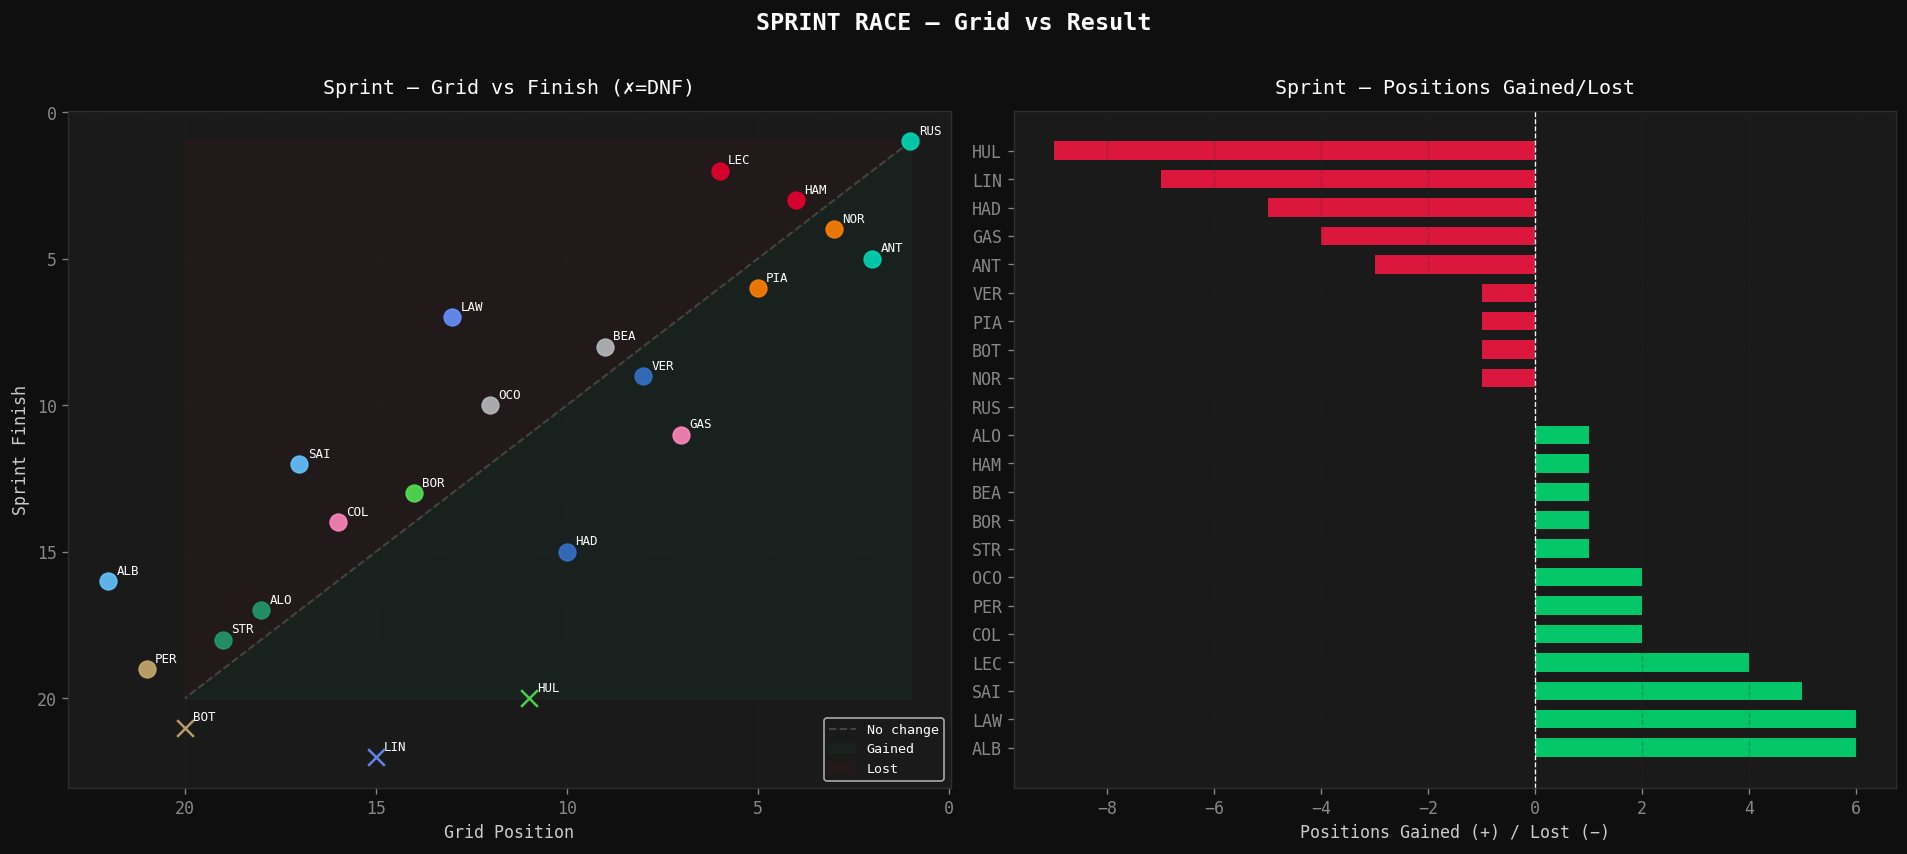

In [40]:
# ── 7.1 Sprint results: grid vs finish ───────────────────────
sprint_r = sprint_res.dropna(subset=['Position','GridPosition']).copy()
sprint_r['positions_gained'] = sprint_r['GridPosition'] - sprint_r['Position']

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('#0f0f0f')

ax = axes[0]
for _, row in sprint_r.iterrows():
    c = TEAM_COLORS.get(row['Team'],'#888888')
    m = 'x' if row['dnf'] else 'o'
    ax.scatter(row['GridPosition'], row['Position'],
               color=c, s=100, marker=m, alpha=0.9, zorder=5)
    ax.annotate(row['Driver'], (row['GridPosition'], row['Position']),
                textcoords='offset points', xytext=(5,4), fontsize=7.5, color='white')
ax.plot([1,20],[1,20],'--', color='#444', linewidth=1.2, label='No change')
ax.fill_between([1,20],[1,20],[20,20], alpha=0.04, color='#00e676', label='Gained')
ax.fill_between([1,20],[1,1],[1,20],   alpha=0.04, color='#ff1744', label='Lost')
ax.set_xlabel('Grid Position'); ax.set_ylabel('Sprint Finish')
ax.set_title('Sprint — Grid vs Finish (✗=DNF)', color='white', pad=10)
ax.legend(facecolor='#1a1a1a', labelcolor='white', fontsize=8)
ax.invert_yaxis(); ax.invert_xaxis(); ax.grid(alpha=0.2)

ax2 = axes[1]
pg = sprint_r.sort_values('positions_gained', ascending=False)
bar_c = ['#00e676' if v>0 else '#ff1744' if v<0 else '#888' for v in pg['positions_gained']]
ax2.barh(pg['Driver'], pg['positions_gained'], color=bar_c, alpha=0.85, height=0.65)
ax2.axvline(0, color='white', linewidth=0.8, linestyle='--')
ax2.set_xlabel('Positions Gained (+) / Lost (−)')
ax2.set_title('Sprint — Positions Gained/Lost', color='white', pad=10)
ax2.grid(axis='x', alpha=0.3)

plt.suptitle('SPRINT RACE — Grid vs Result',
             color='white', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); savefig('04_sprint_race.png'); plt.show()


  💾 ./figures_eda/05_sprint_laps.png


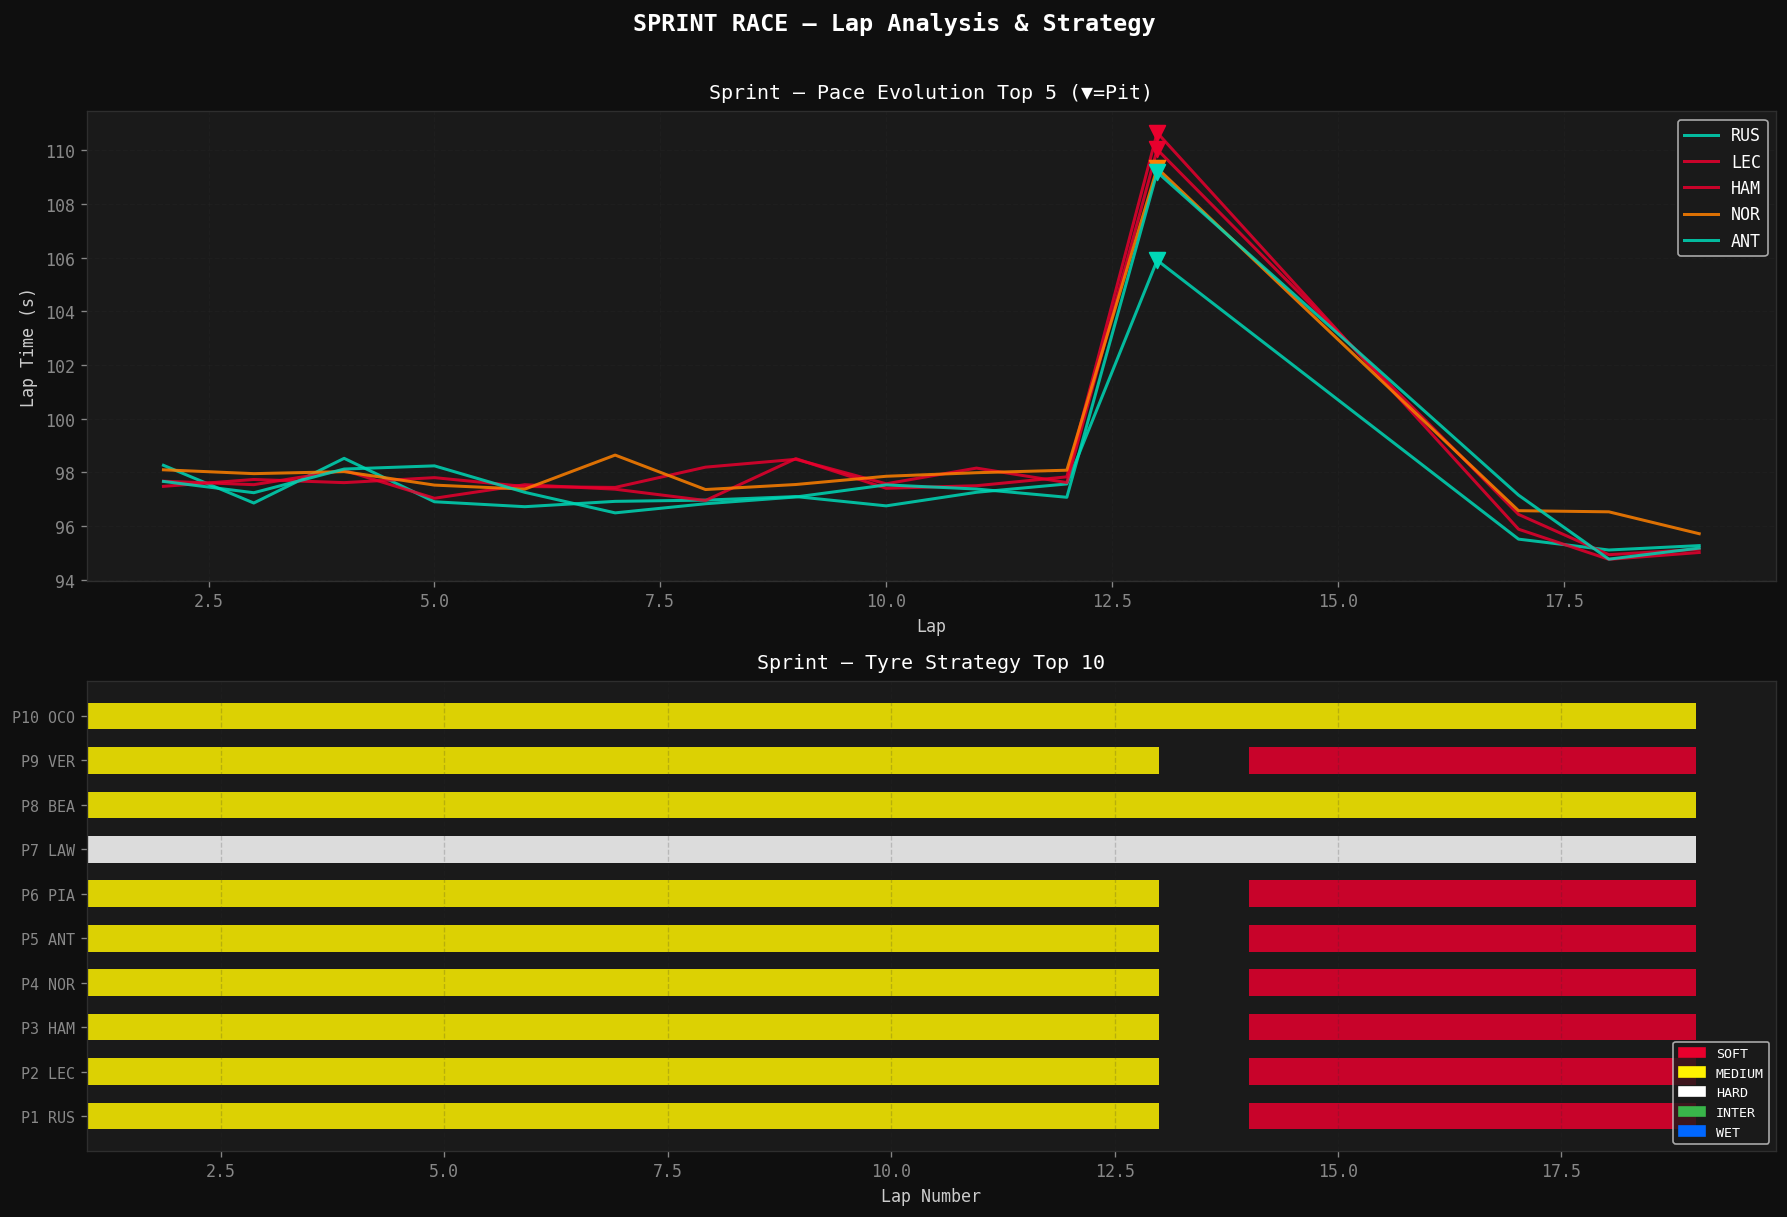

In [41]:
# ── 7.2 Sprint lap evolution + tyre strategy ─────────────────
top5_sprint = sprint_res.dropna(subset=['Position'])\
    .sort_values('Position').head(5)['Driver'].tolist()

fig, axes = plt.subplots(2, 1, figsize=(15, 10))
fig.patch.set_facecolor('#0f0f0f')

# Top: lap evolution
ax = axes[0]
for driver in top5_sprint:
    drv = sprint_laps[(sprint_laps['Driver']==driver) &
                      sprint_laps['LapTime_s'].notna() &
                      (sprint_laps['LapTime_s']<120)]
    c = driver_color.get(driver,'#888888')
    ax.plot(drv['LapNumber'], drv['LapTime_s'],
            color=c, linewidth=1.8, alpha=0.85, label=driver)
    pits = drv[drv['PitInTime_s'].notna()]
    if not pits.empty:
        ax.scatter(pits['LapNumber'], pits['LapTime_s'],
                   color=c, marker='v', s=90, zorder=6)
ax.set_xlabel('Lap'); ax.set_ylabel('Lap Time (s)')
ax.set_title('Sprint — Pace Evolution Top 5 (▼=Pit)', color='white', pad=8)
ax.legend(facecolor='#1a1a1a', labelcolor='white'); ax.grid(alpha=0.25)

# Bottom: tyre strategy
top10_sprint = sprint_res.dropna(subset=['Position'])\
    .sort_values('Position').head(10)['Driver'].tolist()
ax2 = axes[1]
for i, driver in enumerate(top10_sprint):
    for _, lap in sprint_laps[sprint_laps['Driver']==driver]\
            .sort_values('LapNumber').iterrows():
        comp = str(lap['Compound']) if pd.notna(lap.get('Compound')) else 'UNKNOWN'
        ax2.barh(i, 1, left=lap['LapNumber']-1, height=0.6,
                color=TYRE_COLORS.get(comp,'#555'), alpha=0.85)
ax2.set_yticks(range(len(top10_sprint)))
ax2.set_yticklabels([f'P{i+1} {d}' for i,d in enumerate(top10_sprint)], fontsize=9)
ax2.set_xlabel('Lap Number')
ax2.set_title('Sprint — Tyre Strategy Top 10', color='white', pad=8)
ax2.legend(handles=[mpatches.Patch(color=c,label=t) for t,c in TYRE_COLORS.items()],
           loc='lower right', facecolor='#1a1a1a', labelcolor='white', fontsize=8)
ax2.grid(axis='x', alpha=0.2)

plt.suptitle('SPRINT RACE — Lap Analysis & Strategy',
             color='white', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); savefig('05_sprint_laps.png'); plt.show()


## 8. 🏆 Qualifying Analysis

  💾 ./figures_eda/06_qualifying.png


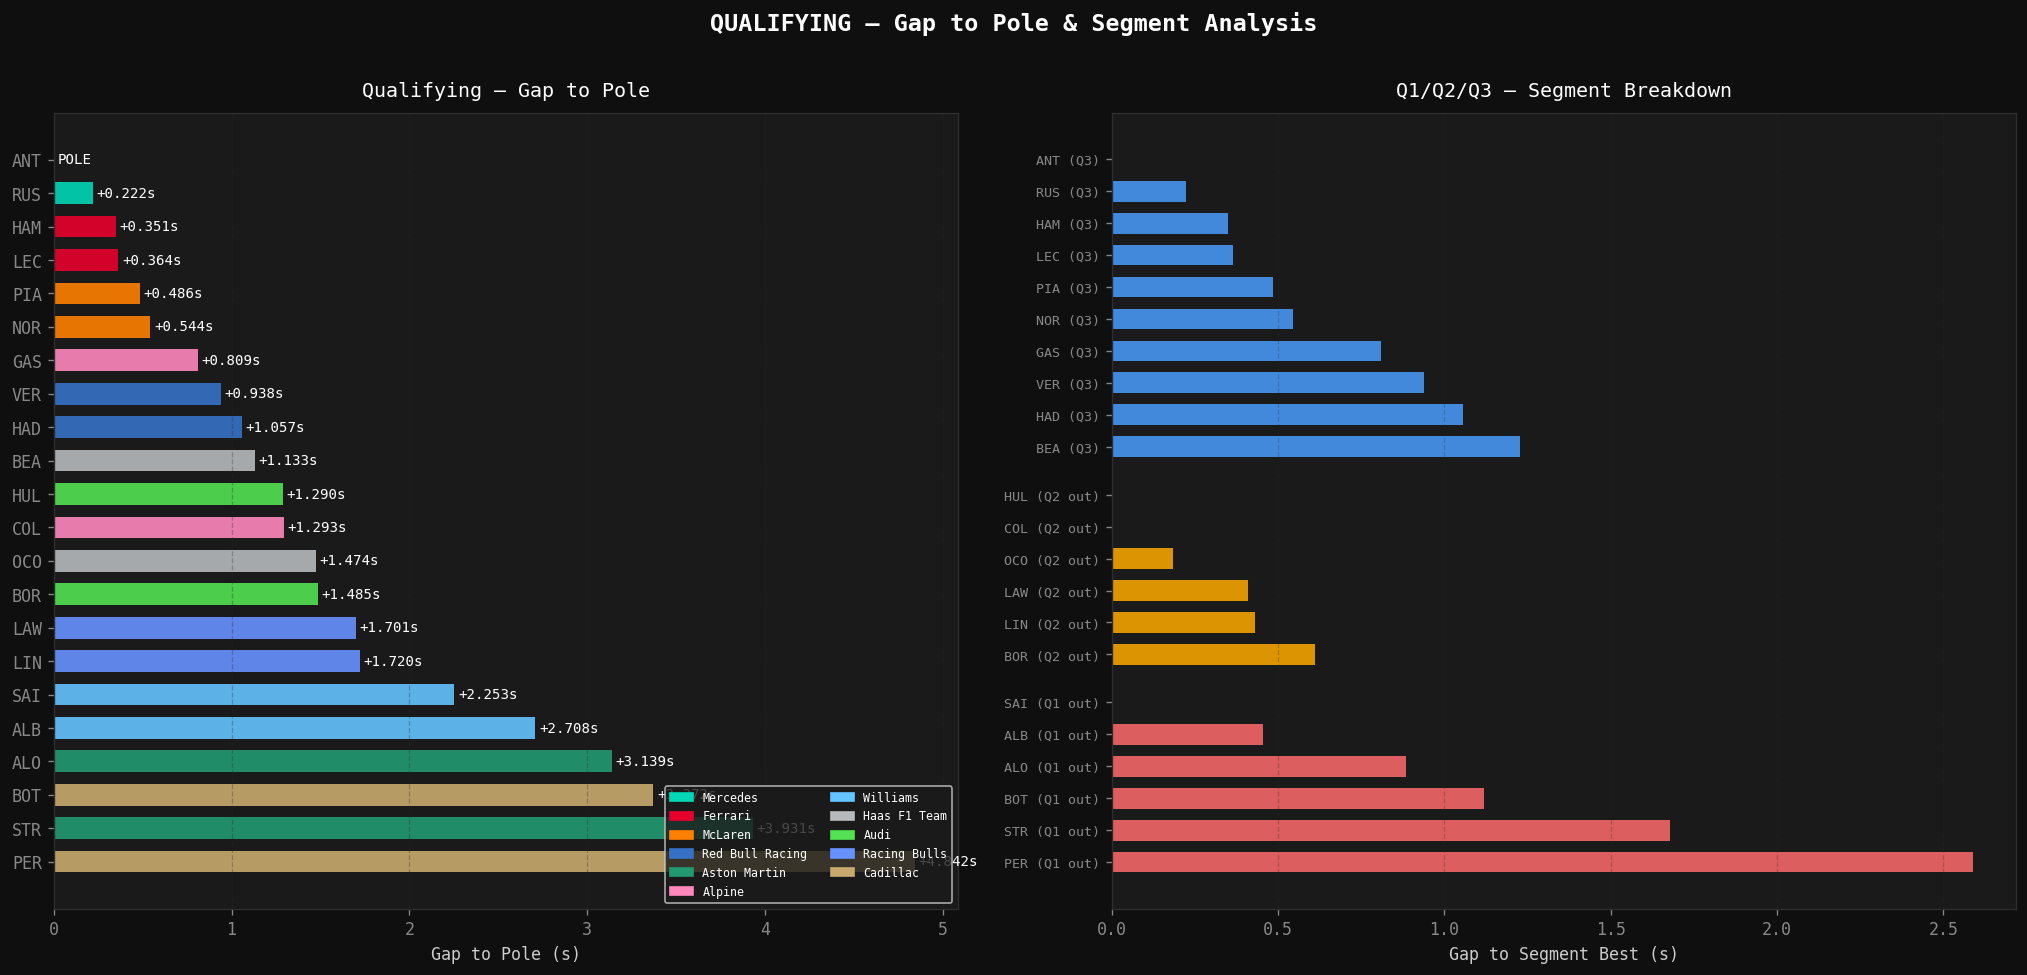

In [42]:
# ── 8.1 Gap to pole ──────────────────────────────────────────
q_plot = q.sort_values('Gap_s').copy()
q_plot['color'] = q_plot['Driver'].map(driver_color)

fig, axes = plt.subplots(1, 2, figsize=(17, 8))
fig.patch.set_facecolor('#0f0f0f')

ax = axes[0]
for _, row in q_plot.iterrows():
    ax.barh(row['Driver'], row['Gap_s'], color=row['color'], alpha=0.9, height=0.65)
    label = f'+{row["Gap_s"]:.3f}s' if row['Gap_s']>0 else 'POLE'
    ax.text(row['Gap_s']+0.02, row['Driver'], label, va='center', fontsize=8.5, color='white')
ax.invert_yaxis()
ax.set_xlabel('Gap to Pole (s)')
ax.set_title('Qualifying — Gap to Pole', color='white', pad=10)
ax.grid(axis='x', alpha=0.3)
ax.legend(handles=[mpatches.Patch(color=c,label=t) for t,c in TEAM_COLORS.items()
                   if t in driver_team.values()],
          loc='lower right', facecolor='#1a1a1a', labelcolor='white', fontsize=7, ncol=2)

# Q1/Q2/Q3 breakdown
ax2 = axes[1]
q3 = q_res[q_res['reached_Q3']].dropna(subset=['Q3_s']).sort_values('Q3_s')
q2 = q_res[q_res['eliminated_Q2']].dropna(subset=['Q2_s']).sort_values('Q2_s')
q1 = q_res[q_res['eliminated_Q1']].dropna(subset=['Q1_s']).sort_values('Q1_s')

y_pos, labels, colors_seg = 0, [], []
segments = [(q3,'Q3_s','Q3','#4a9eff'),(q2,'Q2_s','Q2 out','#ffaa00'),(q1,'Q1_s','Q1 out','#ff6b6b')]
yticks, yticklabels = [], []

offset = 0
for data, col, seg_label, seg_color in segments:
    best = data[col].min()
    for j, (_, row) in enumerate(data.iterrows()):
        gap = row[col]-best
        ax2.barh(offset+j, gap, color=seg_color, alpha=0.85, height=0.65)
        yticks.append(offset+j)
        yticklabels.append(f'{row.Driver} ({seg_label})')
    offset += len(data) + 0.5

ax2.set_yticks(yticks)
ax2.set_yticklabels(yticklabels, fontsize=8)
ax2.invert_yaxis()
ax2.set_xlabel('Gap to Segment Best (s)')
ax2.set_title('Q1/Q2/Q3 — Segment Breakdown', color='white', pad=10)
ax2.grid(axis='x', alpha=0.25)

plt.suptitle('QUALIFYING — Gap to Pole & Segment Analysis',
             color='white', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); savefig('06_qualifying.png'); plt.show()


  💾 ./figures_eda/07_sq_vs_quali.png


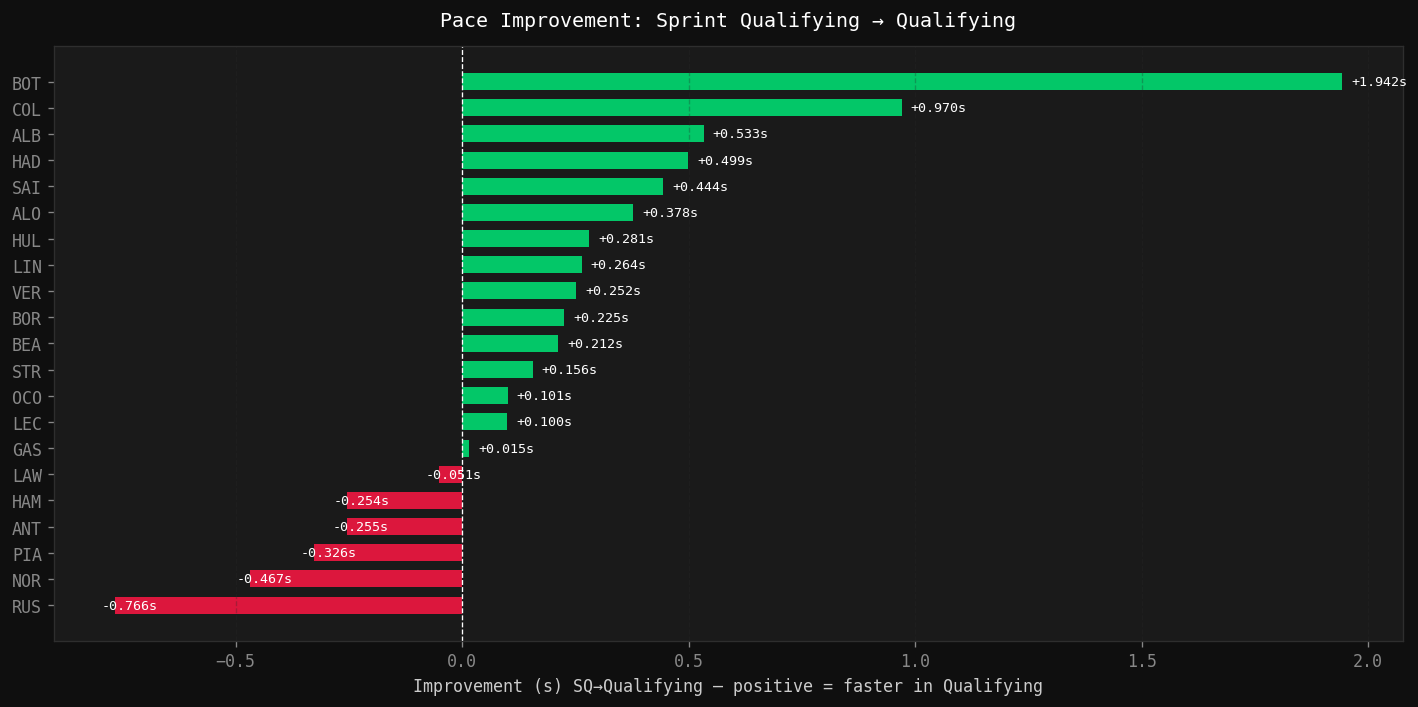

In [43]:
# ── 8.2 SQ vs Qualifying pace comparison ─────────────────────
pace_q = sq[['Driver','LapTime_s']].rename(columns={'LapTime_s':'SQ'})\
    .merge(q[['Driver','LapTime_s']].rename(columns={'LapTime_s':'Qualifying'}), on='Driver')
pace_q['improvement'] = pace_q['SQ'] - pace_q['Qualifying']
pace_q = pace_q.sort_values('Qualifying')

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('#0f0f0f')

imp = pace_q.sort_values('improvement', ascending=True)
bar_c = ['#00e676' if v>=0 else '#ff1744' for v in imp['improvement']]
ax.barh(imp['Driver'], imp['improvement'], color=bar_c, alpha=0.85, height=0.65)
ax.axvline(0, color='white', linewidth=0.8, linestyle='--')
ax.set_xlabel('Improvement (s) SQ→Qualifying — positive = faster in Qualifying')
ax.set_title('Pace Improvement: Sprint Qualifying → Qualifying', color='white', pad=12)
ax.grid(axis='x', alpha=0.3)
for _, row in imp.iterrows():
    v = row['improvement']
    ax.text(v+(0.02 if v>=0 else -0.03), row['Driver'],
            f'{v:+.3f}s', va='center', fontsize=8, color='white')

plt.tight_layout(); savefig('07_sq_vs_quali.png'); plt.show()


## 9. 🏆 Race Analysis

  💾 ./figures_eda/08_race_grid_vs_finish.png


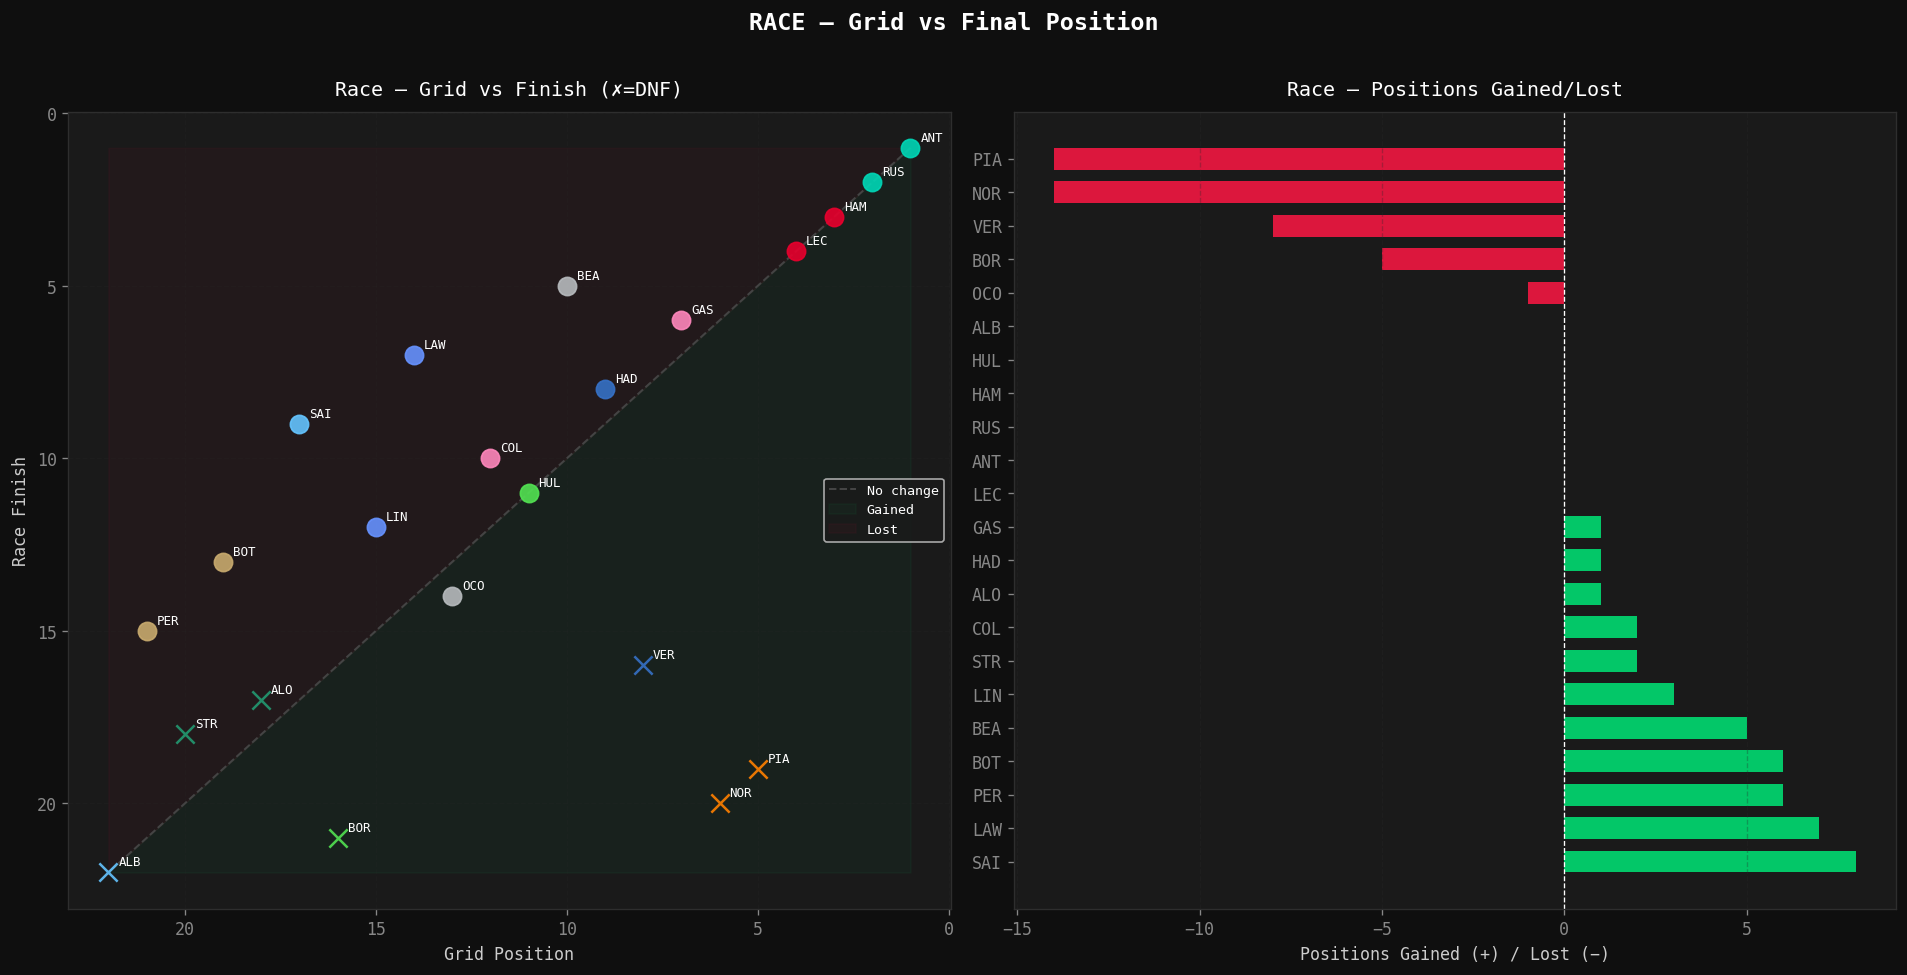

Top 5 gainers:
Driver         Team  GridPosition  Position  positions_gained   Status
   SAI     Williams          17.0       9.0               8.0   Lapped
   LAW Racing Bulls          14.0       7.0               7.0 Finished
   PER     Cadillac          21.0      15.0               6.0   Lapped
   BOT     Cadillac          19.0      13.0               6.0   Lapped
   BEA Haas F1 Team          10.0       5.0               5.0 Finished


In [44]:
# ── 9.1 Grid vs Finish + positions gained ────────────────────
r = r_res.dropna(subset=['Position','GridPosition']).copy()
r['positions_gained'] = r['GridPosition'] - r['Position']

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.patch.set_facecolor('#0f0f0f')

ax = axes[0]
for _, row in r.iterrows():
    c = TEAM_COLORS.get(row['Team'],'#888888')
    m = 'x' if row['dnf'] else 'o'
    ax.scatter(row['GridPosition'], row['Position'],
               color=c, s=120, marker=m, alpha=0.9, zorder=5)
    ax.annotate(row['Driver'], (row['GridPosition'], row['Position']),
                textcoords='offset points', xytext=(6,4), fontsize=7.5, color='white')
ax.plot([1,22],[1,22],'--', color='#444', linewidth=1.2, label='No change')
ax.fill_between([1,22],[1,22],[22,22], alpha=0.04, color='#00e676', label='Gained')
ax.fill_between([1,22],[1,1],[1,22],   alpha=0.04, color='#ff1744', label='Lost')
ax.set_xlabel('Grid Position'); ax.set_ylabel('Race Finish')
ax.set_title('Race — Grid vs Finish (✗=DNF)', color='white', pad=10)
ax.legend(facecolor='#1a1a1a', labelcolor='white', fontsize=8)
ax.invert_yaxis(); ax.invert_xaxis(); ax.grid(alpha=0.2)

ax2 = axes[1]
pg = r.dropna(subset=['positions_gained']).sort_values('positions_gained', ascending=False)
bar_c = ['#00e676' if v>0 else '#ff1744' if v<0 else '#888' for v in pg['positions_gained']]
ax2.barh(pg['Driver'], pg['positions_gained'], color=bar_c, alpha=0.85, height=0.65)
ax2.axvline(0, color='white', linewidth=0.8, linestyle='--')
ax2.set_xlabel('Positions Gained (+) / Lost (−)')
ax2.set_title('Race — Positions Gained/Lost', color='white', pad=10)
ax2.grid(axis='x', alpha=0.3)

plt.suptitle('RACE — Grid vs Final Position',
             color='white', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); savefig('08_race_grid_vs_finish.png'); plt.show()

print('Top 5 gainers:')
print(r.sort_values('positions_gained',ascending=False)
      [['Driver','Team','GridPosition','Position','positions_gained','Status']].head(5).to_string(index=False))


## 10. 🔧 Tyre Strategy

  💾 ./figures_eda/10_race_tyre_strategy.png


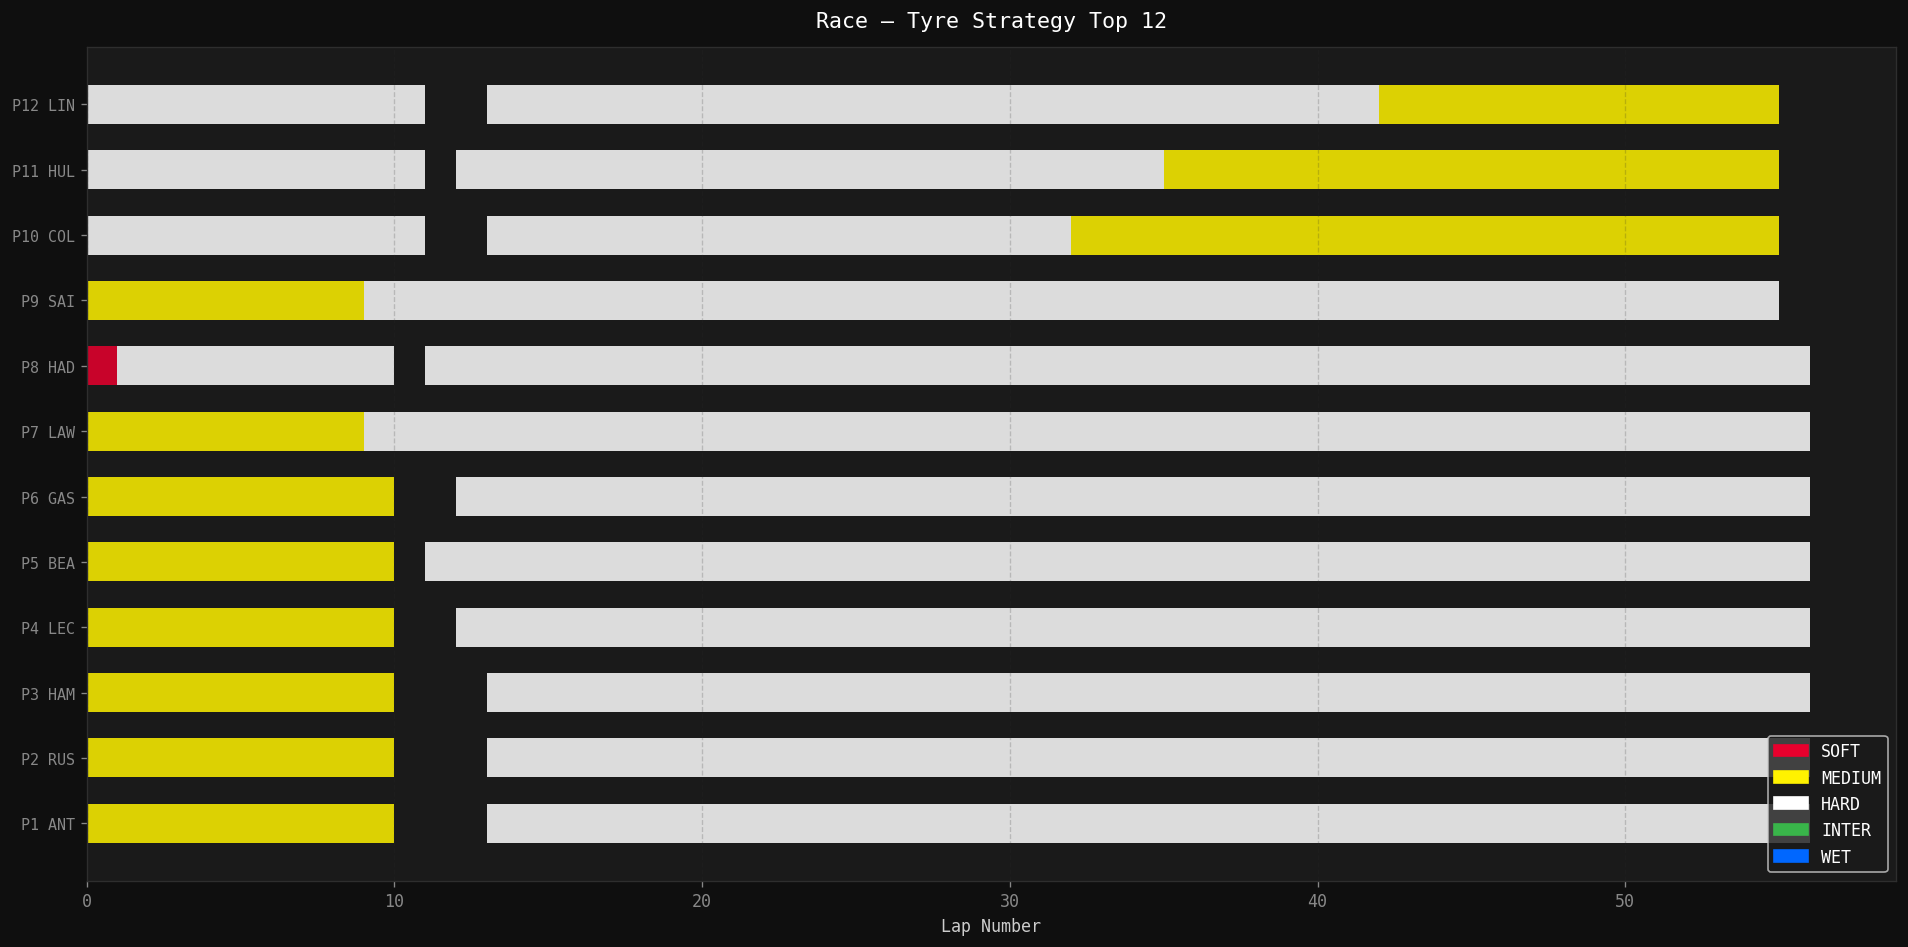

In [45]:
# ── 10.1 Race tyre strategy — Top 12 ────────────────────────
top12 = r_res.dropna(subset=['Position']).sort_values('Position').head(12)['Driver'].tolist()

fig, ax = plt.subplots(figsize=(16, 8))
fig.patch.set_facecolor('#0f0f0f')

for i, driver in enumerate(top12):
    for _, lap in r_laps[r_laps['Driver']==driver].sort_values('LapNumber').iterrows():
        comp = str(lap.get('Compound','')) if pd.notna(lap.get('Compound')) else 'UNKNOWN'
        ax.barh(i, 1, left=lap['LapNumber']-1, height=0.6,
                color=TYRE_COLORS.get(comp,'#555'), alpha=0.85)

ax.set_yticks(range(len(top12)))
ax.set_yticklabels([f'P{i+1} {d}' for i,d in enumerate(top12)], fontsize=9)
ax.set_xlabel('Lap Number')
ax.set_title('Race — Tyre Strategy Top 12', color='white', pad=12, fontsize=13)
ax.legend(handles=[mpatches.Patch(color=c,label=t) for t,c in TYRE_COLORS.items()],
          loc='lower right', facecolor='#1a1a1a', labelcolor='white')
ax.grid(axis='x', alpha=0.2)
plt.tight_layout(); savefig('10_race_tyre_strategy.png'); plt.show()


  💾 ./figures_eda/11_tyre_degradation.png


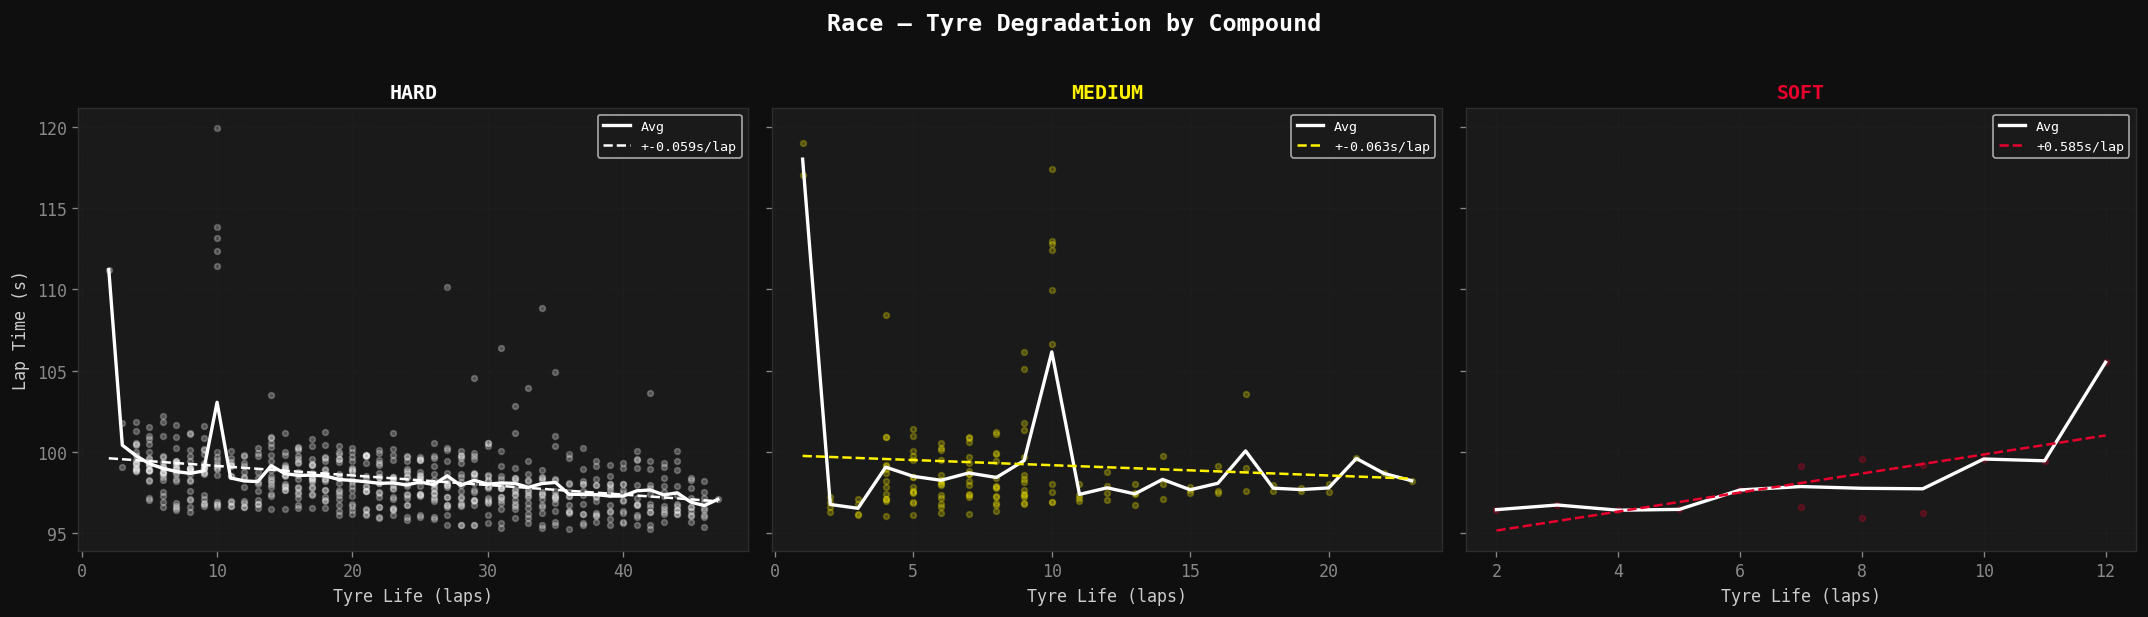

In [46]:
# ── 10.2 Tyre degradation ────────────────────────────────────
deg = r_laps[r_laps['LapTime_s'].notna() & r_laps['TyreLife'].notna() &
             (r_laps['LapTime_s']<120) & (r_laps['LapNumber']>3)].copy()
compounds = sorted(deg['Compound'].dropna().unique())

fig, axes = plt.subplots(1, len(compounds), figsize=(6*len(compounds), 5), sharey=True)
fig.patch.set_facecolor('#0f0f0f')
if len(compounds)==1: axes=[axes]

for ax, comp in zip(axes, compounds):
    data = deg[deg['Compound']==comp]
    c    = TYRE_COLORS.get(comp,'#888')
    ax.scatter(data['TyreLife'], data['LapTime_s'], color=c, alpha=0.25, s=12)
    avg = data.groupby('TyreLife')['LapTime_s'].mean()
    ax.plot(avg.index, avg.values, color='white', linewidth=2, label='Avg')
    if len(data)>5:
        z  = np.polyfit(data['TyreLife'], data['LapTime_s'], 1)
        xl = np.linspace(data['TyreLife'].min(), data['TyreLife'].max(), 100)
        ax.plot(xl, np.poly1d(z)(xl), '--', color=c, linewidth=1.5,
                label=f'+{z[0]:.3f}s/lap')
    ax.set_xlabel('Tyre Life (laps)'); ax.set_title(comp, color=c, fontsize=12, fontweight='bold')
    ax.legend(facecolor='#1a1a1a', labelcolor='white', fontsize=8); ax.grid(alpha=0.25)

axes[0].set_ylabel('Lap Time (s)')
plt.suptitle('Race — Tyre Degradation by Compound',
             color='white', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); savefig('11_tyre_degradation.png'); plt.show()


## 12. 🔍 Correlation & Feature Insights

  💾 ./figures_eda/13_correlation_matrix.png


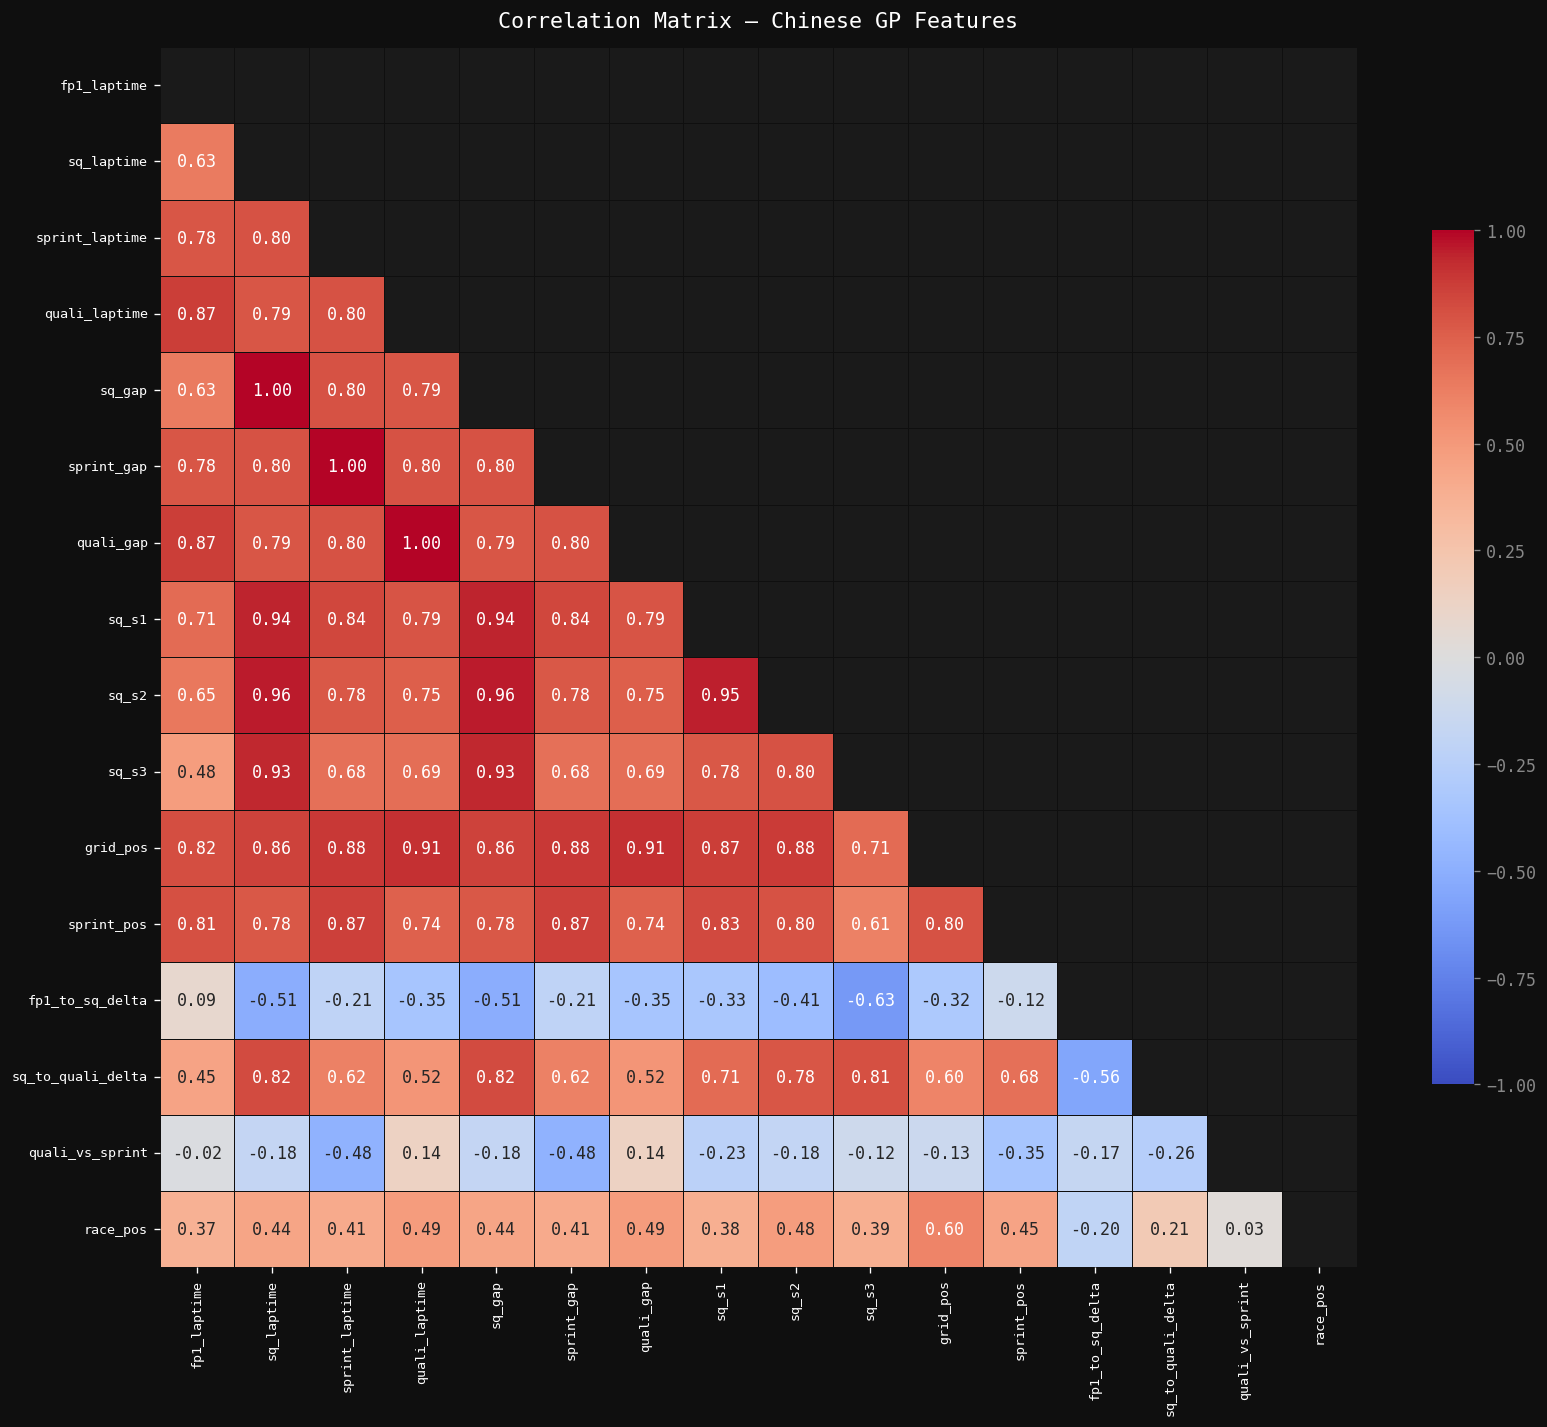


Top correlations with race_pos:
  grid_pos                      : +0.598  ██████████████ (↑ worse)
  quali_gap                     : +0.485  ████████████ (↑ worse)
  quali_laptime                 : +0.485  ████████████ (↑ worse)
  sq_s2                         : +0.484  ████████████ (↑ worse)
  sprint_pos                    : +0.447  ███████████ (↑ worse)
  sq_laptime                    : +0.442  ███████████ (↑ worse)
  sq_gap                        : +0.442  ███████████ (↑ worse)
  sprint_gap                    : +0.413  ██████████ (↑ worse)
  sprint_laptime                : +0.413  ██████████ (↑ worse)
  sq_s3                         : +0.385  █████████ (↑ worse)
  sq_s1                         : +0.383  █████████ (↑ worse)
  fp1_laptime                   : +0.370  █████████ (↑ worse)
  sq_to_quali_delta             : +0.207  █████ (↑ worse)
  fp1_to_sq_delta               : -0.203  █████ (↑ better)
  quali_vs_sprint               : +0.026   (↑ worse)


In [47]:
# ── 12.1 Correlation matrix ──────────────────────────────────
feature_cols = [
    'fp1_laptime','sq_laptime','sprint_laptime','quali_laptime',
    'sq_gap','sprint_gap','quali_gap',
    'sq_s1','sq_s2','sq_s3',
    'grid_pos','sprint_pos',
    'fp1_to_sq_delta','sq_to_quali_delta','quali_vs_sprint',
    'race_pos'
]

corr_data = df_drivers[feature_cols].copy()
corr_data = corr_data.fillna(corr_data.median(numeric_only=True))
corr_matrix = corr_data.corr()

fig, ax = plt.subplots(figsize=(14, 12))
fig.patch.set_facecolor('#0f0f0f')
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, ax=ax, mask=mask,
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f',
            linewidths=0.4, linecolor='#0f0f0f',
            cbar_kws={'shrink':0.7})
ax.set_title('Correlation Matrix — Chinese GP Features', color='white', pad=12, fontsize=13)
ax.tick_params(colors='white', labelsize=8)
plt.tight_layout(); savefig('13_correlation_matrix.png'); plt.show()

print('\nTop correlations with race_pos:')
corr_target = corr_matrix['race_pos'].drop('race_pos').dropna()\
    .sort_values(key=abs, ascending=False)
for feat, val in corr_target.items():
    bar = '█' * int(abs(val)*25)
    direction = '(↑ worse)' if val>0 else '(↑ better)'
    print(f'  {feat:30s}: {val:+.3f}  {bar} {direction}')


  💾 ./figures_eda/14_key_predictors.png


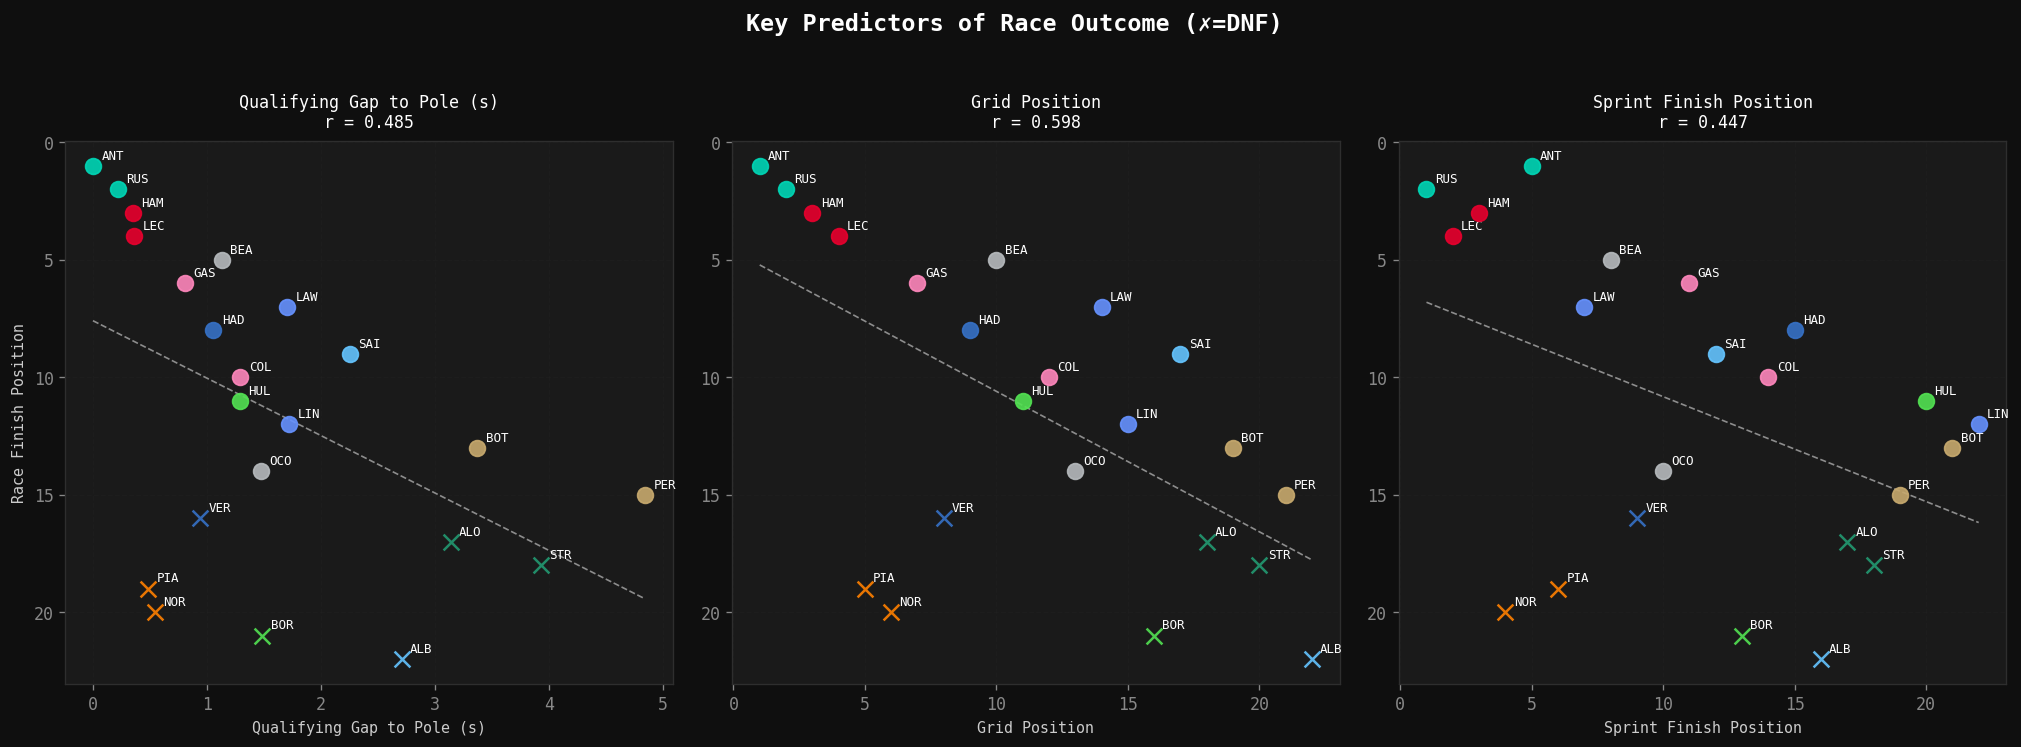

In [48]:
# ── 12.2 Key predictors scatter ──────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 6))
fig.patch.set_facecolor('#0f0f0f')

pairs = [
    ('quali_gap',  'Qualifying Gap to Pole (s)'),
    ('grid_pos',   'Grid Position'),
    ('sprint_pos', 'Sprint Finish Position'),
]

plot_data = df_drivers.dropna(subset=['race_pos']).copy()

for ax, (x_col, x_label) in zip(axes, pairs):
    valid = plot_data.dropna(subset=[x_col,'race_pos'])
    for _, row in valid.iterrows():
        c = TEAM_COLORS.get(row['Team'],'#888888')
        m = 'x' if row['dnf'] else 'o'
        ax.scatter(row[x_col], row['race_pos'],
                   color=c, s=90, marker=m, alpha=0.9, zorder=5)
        ax.annotate(row['Driver'], (row[x_col], row['race_pos']),
                    textcoords='offset points', xytext=(5,4),
                    fontsize=7.5, color='white')
    if len(valid)>2:
        z  = np.polyfit(valid[x_col], valid['race_pos'], 1)
        xl = np.linspace(valid[x_col].min(), valid[x_col].max(), 100)
        ax.plot(xl, np.poly1d(z)(xl), '--', color='white', linewidth=1, alpha=0.5)
        r_val = valid[[x_col,'race_pos']].corr().iloc[0,1]
        ax.set_title(f'{x_label}\nr = {r_val:.3f}', color='white', fontsize=10, pad=8)
    ax.set_xlabel(x_label, fontsize=9)
    if ax==axes[0]: ax.set_ylabel('Race Finish Position', fontsize=9)
    ax.grid(alpha=0.2); ax.invert_yaxis()

plt.suptitle('Key Predictors of Race Outcome (✗=DNF)',
             color='white', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout(); savefig('14_key_predictors.png'); plt.show()


## 13. 💾 Save Processed Data

In [49]:
# df_drivers
df_drivers_save = df_drivers.drop(columns=['pit_laps','team_color'], errors='ignore')
df_drivers_save.to_csv(f'{PROC_DIR}/df_drivers.csv', index=False)

# df_laps
df_laps.to_csv(f'{PROC_DIR}/df_laps.csv', index=False)

# Weather summary
summary_w.to_csv(f'{PROC_DIR}/weather_summary.csv', index=False)

print('✅ Saved:')
print(f'   {PROC_DIR}/df_drivers.csv    — {df_drivers_save.shape}')
print(f'   {PROC_DIR}/df_laps.csv       — {df_laps.shape}')
print(f'   {PROC_DIR}/weather_summary.csv')
print()
print('df_drivers columns:')
for c in df_drivers_save.columns:
    dtype = str(df_drivers_save[c].dtype)
    null  = df_drivers_save[c].isnull().sum()
    print(f'  {c:35s} {dtype:10s} null={null}')
print()
print('📁 Figures saved:')
import glob
for f in sorted(glob.glob(f'{FIG_DIR}/*.png')):
    print(f'   {f}')
print()
print('🎯 Ready for Notebook 02 — Feature Engineering & ML!')


✅ Saved:
   ./processed/df_drivers.csv    — (22, 57)
   ./processed/df_laps.csv       — (2129, 19)
   ./processed/weather_summary.csv

df_drivers columns:
  Driver                              object     null=0
  DriverNumber                        int64      null=0
  fp1_laptime                         float64    null=0
  fp1_s1                              float64    null=0
  fp1_s2                              float64    null=0
  fp1_s3                              float64    null=0
  fp1_speed                           float64    null=0
  fp1_gap                             float64    null=0
  sq_laptime                          float64    null=1
  sq_s1                               float64    null=1
  sq_s2                               float64    null=1
  sq_s3                               float64    null=1
  sq_speed                            float64    null=1
  sq_gap                              float64    null=1
  sprint_laptime                      float64    null=0
  spr

In [50]:
print(df_drivers.columns.tolist())
print(df_drivers.shape)
print(df_drivers.dtypes)

['Driver', 'DriverNumber', 'fp1_laptime', 'fp1_s1', 'fp1_s2', 'fp1_s3', 'fp1_speed', 'fp1_gap', 'sq_laptime', 'sq_s1', 'sq_s2', 'sq_s3', 'sq_speed', 'sq_gap', 'sprint_laptime', 'sprint_s1', 'sprint_s2', 'sprint_s3', 'sprint_speed', 'sprint_gap', 'quali_laptime', 'quali_s1', 'quali_s2', 'quali_s3', 'quali_speed', 'quali_gap', 'Q1_s', 'Q2_s', 'Q3_s', 'eliminated_Q1', 'eliminated_Q2', 'reached_Q3', 'sprint_pos', 'sprint_status', 'sprint_points', 'Team', 'race_pos', 'classified_pos', 'grid_pos', 'race_status', 'race_points', 'race_laps', 'dnf', 'finished', 'positions_gained', 'pit_stops', 'pit_laps', 'first_pit', 'last_pit', 'race_fastest_s', 'race_fastest_speed', 'race_fastest_compound', 'fp1_to_sq_delta', 'sq_to_quali_delta', 'quali_vs_sprint', 'sq_sector_std', 'sprint_sector_std', 'sprint_pos_gained', 'team_color']
(22, 59)
Driver                    object
DriverNumber               int64
fp1_laptime              float64
fp1_s1                   float64
fp1_s2                   float64
